# Detección de crisis epilépticas — extensión a 14 ratas### PSIB 2026 Q1 · Parte 2 · Grupo 5Réplica del pipeline validado en 6 ratas, extendido a **14 ratas** (las 15 de lalista menos C13). Usa las decisiones finales, sin los experimentos intermedios:- **Detector:** CWT `mexh` · z>18 MADs · ≥2 canales · ≥5 s sostenidos · margen 2 s- **Etiquetas:** interictal [0, onset−30] · ictal [onset+10, onset+30]- **ML:** features WPD (db4, nivel 6) → normalización por rata → LORO- **Modelos:** Random Forest y MLP (64,32)**Diferencia con la versión de 6 ratas:** no se corre el control de especificidaddel detector (ya demostrado 0/12 falsos positivos). El `non` se descarga igualporque es **imprescindible para normalizar** las features del ML — sin eso, elmodelo aprende la identidad del animal y LORO se cae (AUC 0.64 vs 0.96).---### ⚠ Cosas a vigilar al correr1. **Ratas que se saltean** (celda 2): si el nombre en el dataset difiere, avisa.2. **B6 debe dar ictal9/ictal10** — control conocido.3. **Onsets censurados** (celda 6): ictales que arrancan en el borde quedan sin   etiqueta. De 28 ictales van a salir menos fragmentos etiquetados.

## 1 · Setup

In [ ]:
# ══ 1 · SETUP ════════════════════════════════════════════════════════════
!pip install dandi pynwb PyWavelets -q

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import signal as sp_sig
from scipy.ndimage import uniform_filter1d
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

BASE = '/content/drive/MyDrive/psib_14ratas'      # carpeta nueva, no pisa la de 6
for sub in ('senales', 'senales_non', 'cache'):
    os.makedirs(f'{BASE}/{sub}', exist_ok=True)

LABELS = ['R_SUB','R_DG','R_CA1','R_CA3','R_AMD','R_ANT',
          'L_SUB','L_DG','L_CA1','L_CA3','L_AMD','L_ANT']
FS_ORIG, FS = 1000, 500
FREQS = np.logspace(np.log10(2), np.log10(200), 32)

# ── parámetros FINALES del detector (validados en 6 ratas) ──────────────
WAVELET   = 'mexh'
K_MAD     = 18
MIN_CAN   = 2
DUR_S     = 5.0
SUAV_S    = 0.25
MARGEN_S  = 2.0
BANDAS = {'delta':(1,4), 'theta_alpha':(4,12), 'beta':(13,30),
          'gamma':(30,80), 'alta':(80,200)}

# ── 15 de Lu menos C13 = 14 ─────────────────────────────────────────────
RATAS = ['RatB6','RatC3','RatC16','RatD17','RatE2','RatE5',
         'Rat4','Rat7','Rat8','RatR2','RatR3','RatR5','RatR6','RatZ11']
N_ICTALES = 2
DANDISET_ID, VER = "001044", "0.240905.0159"

print(f'{WAVELET} · z>{K_MAD} · ≥{MIN_CAN} canales · ≥{DUR_S}s · margen {MARGEN_S}s')
print(f'{len(RATAS)} ratas · {N_ICTALES} ictales c/u')

Mounted at /content/drive
mexh · z>18 · ≥2 canales · ≥5.0s · margen 2.0s
14 ratas · 2 ictales c/u


## 2 · Selección de archivos (no descarga aún)Solo lista qué se va a bajar, para verificar antes de gastar la descarga.Criterio: los 2 ictales más recientes (late) + el `non` de fecha más cercana.

In [ ]:
# ══ 2 · PLAN DE DESCARGA (solo mira) ═════════════════════════════════════
print(f'Buscando archivos de {len(RATAS)} ratas...\n')
PLAN = {}
with DandiAPIClient() as cl:
    ds = cl.get_dandiset(DANDISET_ID, VER)
    assets = list(ds.get_assets())
    for rata in RATAS:
        ict = sorted([(a.path.split('/')[-1].split('ses-')[1][:8],
                       a.path.split('/')[-1], a) for a in assets
                      if f'{rata}_' in a.path.split('/')[-1] and '-ictal' in a.path
                      and '-small' not in a.path])
        non = sorted([(a.path.split('/')[-1].split('ses-')[1][:8],
                       a.path.split('/')[-1], a) for a in assets
                      if f'{rata}_' in a.path.split('/')[-1] and '-non' in a.path])
        if len(ict) < N_ICTALES or not non:
            print(f'  ✗ {rata}: {len(ict)} ictales, {len(non)} non → SE SALTEA')
            continue
        sel_ict = ict[-N_ICTALES:]
        f_obj = int(sel_ict[0][0])
        sel_non = min(non, key=lambda x: abs(int(x[0])-f_obj))
        PLAN[rata] = {'ictales': sel_ict, 'non': sel_non}

mb = 0
print(f'\n{"rata":<8s}{"ictal 1":>26s}{"ictal 2":>26s}{"non":>22s}')
print('-'*82)
for rata, p in PLAN.items():
    i1, i2 = p['ictales']
    mb += sum(a.size for _,_,a in p['ictales']) + p['non'][2].size
    print(f'{rata:<8s}{i1[1].split("ses-")[1][:18]:>26s}'
          f'{i2[1].split("ses-")[1][:18]:>26s}{p["non"][1].split("ses-")[1][:14]:>22s}')
print(f'\n  {len(PLAN)} ratas listas · {len(PLAN)*N_ICTALES} ictales + {len(PLAN)} non · ~{mb/1e6:.0f} MB')
print('  ⚠ Verificá que RatB6 dé ictal9 e ictal10.')

Buscando archivos de 14 ratas...

  ✗ Rat4: 0 ictales, 0 non → SE SALTEA
  ✗ Rat7: 0 ictales, 0 non → SE SALTEA
  ✗ Rat8: 0 ictales, 0 non → SE SALTEA

rata                       ictal 1                   ictal 2                   non
----------------------------------------------------------------------------------
RatB6           20230724-ictal9_ec        20230725-ictal10_e        20230723-non_e
RatC3           20231023-ictal23_e        20231024-ictal23_e        20231020-non_e
RatC16          20231030-ictal10_e        20231031-ictal1_ec        20231101-non_e
RatD17          20240104-ictal9_ec        20240105-ictal15_e        20240102-non_e
RatE2           20190703-ictal1_ec        20190707-ictal2_ec        20190705-non_e
RatE5           20190531-ictal3_ec        20190601-ictal6_ec        20190526-non_e
RatR2           20220429-ictal12_e        20220430-ictal11_e        20220425-non_e
RatR3           20220319-ictal30_e        20220320-ictal29_e        20220316-non_e
RatR5           20

## 3 · Descarga y decimado a 500 HzBaja los archivos del PLAN, decima 1000→500 Hz, guarda en Drive.Se cachea: si la sesión se corta, volvé a correr y retoma lo que falta.Preprocesamiento: **ninguno** (el paper ya aplicó notch y pasabanda).

In [ ]:
# ══ 3 · DESCARGA + DECIMADO ══════════════════════════════════════════════
def decimar(raw):
    n = len(sp_sig.decimate(raw[:,0], FS_ORIG//FS, ftype='fir', zero_phase=True))
    o = np.zeros((n,12), dtype=np.float32)
    for c in range(12):
        o[:,c] = sp_sig.decimate(raw[:,c], FS_ORIG//FS, ftype='fir', zero_phase=True)
    return o

with DandiAPIClient() as cl:
    ds = cl.get_dandiset(DANDISET_ID, VER)
    for rata, p in PLAN.items():
        # ictales → primera serie de cada archivo
        for _, nom, a in p['ictales']:
            tmp = f'/content/{nom}'
            if not os.path.exists(tmp): a.download(tmp)
            io = NWBHDF5IO(tmp, mode='r', load_namespaces=True); nwb = io.read()
            s = sorted(nwb.acquisition.keys())[0]
            dst = f'{BASE}/senales/{s}.npz'
            if not os.path.exists(dst):
                np.savez_compressed(dst, sig=decimar(nwb.acquisition[s].data[:]), rata=rata)
            io.close(); os.remove(tmp)
            print(f'  ✓ {rata:8s} ictal {s}')
        # non → las 2 series
        _, nom, a = p['non']
        tmp = f'/content/{nom}'
        if not os.path.exists(tmp): a.download(tmp)
        io = NWBHDF5IO(tmp, mode='r', load_namespaces=True); nwb = io.read()
        for s in sorted(nwb.acquisition.keys()):
            dst = f'{BASE}/senales_non/{s}.npz'
            if not os.path.exists(dst):
                np.savez_compressed(dst, sig=decimar(nwb.acquisition[s].data[:]), rata=rata)
        io.close(); os.remove(tmp)
        print(f'  ✓ {rata:8s} non ({len(nwb.acquisition)} series)')

print('\nDescarga completa.')

INFO:dandi:Asset b62a0af4-03a8-46d2-a8af-c803d9bb5f86 (195189494 bytes in 24 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/b62a0af4-03a8-46d2-a8af-c803d9bb5f86/download/


  ✓ RatB6    ictal B6_2023_7_24-ictal1


INFO:dandi:Asset 59c37d97-83d9-45ea-9dec-5835b6d1243a (223151536 bytes in 27 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/59c37d97-83d9-45ea-9dec-5835b6d1243a/download/


  ✓ RatB6    ictal B6_2023_7_25-ictal1


INFO:dandi:Asset fa897829-d39a-4ce6-88b4-6f4af4bc3220 (44332201 bytes in 6 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/fa897829-d39a-4ce6-88b4-6f4af4bc3220/download/


...

  ✓ RatZ11   ictal Z11_2021_11_19-ictal1


INFO:dandi:Asset 2d96efeb-3aaa-4bbe-89fc-f6413c454a75 (21561159 bytes in 3 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/2d96efeb-3aaa-4bbe-89fc-f6413c454a75/download/


  ✓ RatZ11   ictal Z11_2021_11_20-ictal1


INFO:dandi:Asset 70203f54-060b-4118-bdc9-8bcb14145979 (40837929 bytes in 5 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/70203f54-060b-4118-bdc9-8bcb14145979/download/


  ✓ RatZ11   non (2 series)

Descarga completa.


## 4 · Cargar señales desde disco

In [ ]:
# ══ 4 · CARGAR ═══════════════════════════════════════════════════════════
def cargar(carpeta):
    D = {}
    for f in sorted(glob.glob(f'{BASE}/{carpeta}/*.npz')):
        fid = os.path.basename(f)[:-4]
        d = np.load(f, allow_pickle=True)
        D[fid] = {'sig': d['sig'], 'rata': str(d['rata'])}
    return D

FRAG, NONS = cargar('senales'), cargar('senales_non')
ratas = sorted({d['rata'] for d in FRAG.values()})
print(f'{len(FRAG)} ictales · {len(NONS)} non · {len(ratas)} ratas\n')
for fid in sorted(FRAG, key=lambda x: FRAG[x]['rata']):
    print(f'  {FRAG[fid]["rata"]:8s} {fid:26s} {FRAG[fid]["sig"].shape}')

22 ictales · 22 non · 11 ratas

  RatB6    B6_2023_7_24-ictal1        (300000, 12)
  RatB6    B6_2023_7_25-ictal1        (300000, 12)
  RatC16   C16_2023_10_30-ictal1      (300000, 12)
  RatC16   C16_2023_10_31-ictal1      (300000, 12)
  RatC3    C3_2023_10_23-ictal1       (300000, 12)
  RatC3    C3_2023_10_24-ictal1       (300000, 12)
  RatD17   D17_2024_1_4-ictal1        (300000, 12)
  RatD17   D17_2024_1_5-ictal1        (300000, 12)
  RatE2    E2_2019_7_3-ictal1         (300000, 12)
  RatE2    E2_2019_7_7-ictal1         (300000, 12)
  RatE5    E5_2019_5_31-ictal1        (300000, 12)
  RatE5    E5_2019_6_1-ictal1         (300000, 12)
  RatR2    R2_2022_4_29-ictal1        (300000, 12)
  RatR2    R2_2022_4_30-ictal1        (300000, 12)
  RatR3    R3_2022_3_19-ictal1        (300000, 12)
  RatR3    R3_2022_3_20-ictal1        (300000, 12)
  RatR5    R5_2022_4_22-ictal1        (300000, 12)
  RatR5    R5_2022_4_23-ictal1        (300000, 12)
  RatR6    R6_2022_4_27-ictal1        (300000, 12)

## 5 · Detector: CWT mexh → z(t) → onsetMotor final validado. Calcula `z(t)` de los 12 canales de cada fragmento(ictales y non). Se cachea en disco (~15 min la primera vez con 42 fragmentos).

In [ ]:
# ══ 5 · MOTOR + z(t) ═════════════════════════════════════════════════════
def cwt_potencia(x):
    fc = pywt.central_frequency(WAVELET)
    coef, _ = pywt.cwt(x, fc*FS/FREQS, WAVELET, sampling_period=1/FS, method='fft')
    return np.abs(coef)**2

def z_agnostico(pot):
    n = max(1, int(SUAV_S*FS)); zs = []
    for (f0,f1) in BANDAS.values():
        m = (FREQS>=f0) & (FREQS<=f1)
        if m.sum()==0: continue
        w = uniform_filter1d(pot[m,:].mean(axis=0), size=n)
        med = np.median(w); mad = np.median(np.abs(w-med))+1e-12
        zs.append((w-med)/mad)
    return np.max(np.vstack(zs), axis=0)

def z_de(fid, sig):
    f = f'{BASE}/cache/{fid}__{WAVELET}.npz'
    if os.path.exists(f): return np.load(f)['z']
    zs = np.vstack([z_agnostico(cwt_potencia(sig[:,c])) for c in range(12)])
    np.savez_compressed(f, z=zs.astype(np.float32))
    return zs

print('Calculando z (ictales)...')
Z_ICT = {}
for k, (fid, d) in enumerate(FRAG.items()):
    Z_ICT[fid] = z_de(fid, d['sig'])
    if (k+1) % 5 == 0: print(f'  {k+1}/{len(FRAG)}')
print('Calculando z (non)...')
Z_NON = {}
for k, (fid, d) in enumerate(NONS.items()):
    Z_NON[fid] = z_de(fid, d['sig'])
    if (k+1) % 5 == 0: print(f'  {k+1}/{len(NONS)}')
print(f'  ✓ {len(Z_ICT)} ictales · {len(Z_NON)} non')

Calculando z (ictales)...
  5/22
  10/22
  15/22
  20/22
Calculando z (non)...
  5/22
  10/22
  15/22
  20/22
  ✓ 22 ictales · 22 non


## 6 · Detección de onset + generación de etiquetasCriterio: primer instante con ≥2 canales sobre z=18 sostenido 5 s, margen 2 s.Etiquetas por fragmento:- **interictal** = [0, onset−30]- **ictal** = [onset+10, onset+30]  (el paper garantiza crisis >30 s)- **onset censurado** (≤ margen) → sin etiqueta, no aporta al ML- **non** = interictal completo (clase 0, sin heurística)

In [ ]:
# ══ 6 · ONSET + ETIQUETAS ════════════════════════════════════════════════
def detectar(zs, k=K_MAD, min_can=MIN_CAN, dur_s=DUR_S, margen=MARGEN_S):
    act = (zs > k).sum(axis=0)
    ok = act >= min_can
    n_m = int(margen*FS); ok[:n_m]=False; ok[-n_m:]=False
    d = np.diff(ok.astype(int))
    ini = np.where(d==1)[0]+1; fin = np.where(d==-1)[0]+1
    if ok[0]: ini = np.r_[0, ini]
    if ok[-1]: fin = np.r_[fin, len(ok)]
    for i,f in zip(ini,fin):
        if f-i >= int(dur_s*FS):
            return {'onset': i/FS, 'n_max': int(act[i:f].max()),
                    'censurado': i/FS <= margen+0.1}
    return None

MARGEN_PRE, MARGEN_POST, DUR_ICTAL = 30.0, 10.0, 30.0
etiquetas = {}
print(f'{"fragmento":<26s}{"rata":>8s}{"onset":>9s}{"estado":>16s}')
print('-'*60)
n_ok = n_cens = n_sin = 0
for fid in sorted(FRAG, key=lambda x: FRAG[x]['rata']):
    r = detectar(Z_ICT[fid])
    if r is None:
        print(f'{fid:<26s}{FRAG[fid]["rata"]:>8s}{"—":>9s}{"sin detección":>16s}'); n_sin+=1; continue
    if r['censurado']:
        print(f'{fid:<26s}{FRAG[fid]["rata"]:>8s}{r["onset"]:>7.1f}s{"censurado":>16s}'); n_cens+=1; continue
    T = FRAG[fid]['sig'].shape[0]/FS
    o = r['onset']
    etiquetas[fid] = {'rata': FRAG[fid]['rata'], 'onset': o,
                      'interictal': (0.0, max(0.0, o-MARGEN_PRE)),
                      'ictal': (o+MARGEN_POST, min(T, o+DUR_ICTAL))}
    print(f'{fid:<26s}{FRAG[fid]["rata"]:>8s}{o:>7.1f}s{"✓ etiquetado":>16s}'); n_ok+=1

# non → interictal completo
for fid, d in NONS.items():
    etiquetas[fid] = {'rata': d['rata'], 'onset': None,
                      'interictal': (0.0, d['sig'].shape[0]/FS), 'ictal': None}

np.save(f'{BASE}/etiquetas.npy', etiquetas)
print(f'\n  ictales etiquetados: {n_ok} · censurados: {n_cens} · sin detección: {n_sin}')
print(f'  non (clase 0): {len(NONS)}')
print(f'  ✓ etiquetas.npy · {len(etiquetas)} fragmentos totales')

fragmento                     rata    onset          estado
------------------------------------------------------------
B6_2023_7_24-ictal1          RatB6  317.6s    ✓ etiquetado
B6_2023_7_25-ictal1          RatB6  298.2s    ✓ etiquetado
C16_2023_10_30-ictal1       RatC16  283.1s    ✓ etiquetado
C16_2023_10_31-ictal1       RatC16  272.7s    ✓ etiquetado
C3_2023_10_23-ictal1         RatC3  325.9s    ✓ etiquetado
C3_2023_10_24-ictal1         RatC3  349.1s    ✓ etiquetado
D17_2024_1_4-ictal1         RatD17  305.1s    ✓ etiquetado
D17_2024_1_5-ictal1         RatD17  273.8s    ✓ etiquetado
E2_2019_7_3-ictal1           RatE2  334.6s    ✓ etiquetado
E2_2019_7_7-ictal1           RatE2  274.6s    ✓ etiquetado
E5_2019_5_31-ictal1          RatE5  364.7s    ✓ etiquetado
E5_2019_6_1-ictal1           RatE5  343.3s    ✓ etiquetado
R2_2022_4_29-ictal1          RatR2    2.0s       censurado
R2_2022_4_30-ictal1          RatR2  273.4s    ✓ etiquetado
R3_2022_3_19-ictal1          RatR3        —   sin det

## 7 · Ventaneo (2 s, paso 1 s) — hereda las etiquetas

In [ ]:
# ══ 7 · VENTANEO ═════════════════════════════════════════════════════════
SIG = {}
for fid in FRAG: SIG[fid] = FRAG[fid]['sig']
for fid in NONS: SIG[fid] = NONS[fid]['sig']

WIN_S, STEP_S = 2.0, 1.0
VENTANAS = []
for fid, e in etiquetas.items():
    T = SIG[fid].shape[0]/FS; t = 0.0
    while t+WIN_S <= T:
        tf = t+WIN_S; clase = None
        if e['interictal'][0] <= t and tf <= e['interictal'][1]: clase = 0
        elif e['ictal'] and e['ictal'][0] <= t and tf <= e['ictal'][1]: clase = 1
        if clase is not None: VENTANAS.append((fid, e['rata'], t, clase))
        t += STEP_S

n0 = sum(1 for v in VENTANAS if v[3]==0); n1 = sum(1 for v in VENTANAS if v[3]==1)
print(f'{len(VENTANAS)} ventanas · interictal {n0} · ictal {n1} · desbalance {n0/max(n1,1):.0f}:1')
print(f'\n{"rata":<9s}{"interictal":>12s}{"ictal":>8s}')
print('-'*30)
for r in ratas:
    v=[x for x in VENTANAS if x[1]==r]
    print(f'{r:<9s}{sum(1 for x in v if x[3]==0):>12d}{sum(1 for x in v if x[3]==1):>8d}')

18403 ventanas · interictal 18061 · ictal 342 · desbalance 53:1

rata       interictal   ictal
------------------------------
RatB6            1751      36
RatC16           1691      36
RatC3            1810      36
RatD17           1714      36
RatE2            1744      36
RatE5            1843      36
RatR2            1440      18
RatR3            1198       0
RatR5            1699      36
RatR6            1682      36
RatZ11           1489      36


## 8 · Features con WPDWPD (db4, nivel 6) → 5 energías relativas por banda + entropía = 6 por canal× 12 = 72 features. Energía **relativa** (no absoluta) para no codificar laamplitud del electrodo. Se cachea en disco.

In [ ]:
# ══ 8 · FEATURES WPD ═════════════════════════════════════════════════════
WAVELET_F, NIVEL = 'db4', 6
N_NODOS = 2**NIVEL; BW = (FS/2)/N_NODOS
NODOS = {nom: [i for i in range(N_NODOS) if (i*BW < f1) and ((i+1)*BW > f0)]
         for nom,(f0,f1) in BANDAS.items()}
NOMBRES = [f'{b}_{ch}' for ch in LABELS for b in list(BANDAS)+['entropia']]

def features_canal(x):
    wp = pywt.WaveletPacket(x, WAVELET_F, maxlevel=NIVEL)
    nodos = wp.get_level(NIVEL, 'freq')          # 'freq' NO 'natural'
    E = np.array([np.sum(n.data**2) for n in nodos])
    Eb = np.array([E[NODOS[b]].sum() for b in BANDAS])
    rel = Eb/(Eb.sum()+1e-12)
    ent = -np.sum(rel*np.log2(rel+1e-12))
    return np.r_[rel, ent]

fcache = f'{BASE}/features_wpd.npz'
if os.path.exists(fcache):
    d = np.load(fcache, allow_pickle=True)
    X, y, grupo, origen = d['X'], d['y'], d['grupo'], d['origen']
    print(f'Features cargadas de cache: {X.shape}')
else:
    print(f'Calculando features de {len(VENTANAS)} ventanas...')
    X, y, grupo, origen = [], [], [], []
    for k,(fid,rata,t0,clase) in enumerate(VENTANAS):
        if k%3000==0: print(f'  {k}/{len(VENTANAS)}')
        i0 = int(t0*FS); seg = SIG[fid][i0:i0+int(WIN_S*FS), :]
        X.append(np.concatenate([features_canal(seg[:,c]) for c in range(12)]))
        y.append(clase); grupo.append(rata); origen.append(fid)
    X=np.array(X); y=np.array(y); grupo=np.array(grupo); origen=np.array(origen)
    np.savez_compressed(fcache, X=X, y=y, grupo=grupo, origen=origen, nombres=NOMBRES)
    print('  ✓ features_wpd.npz')

print(f'\nX: {X.shape} · y: {np.sum(y==0)} interictal / {np.sum(y==1)} ictal')
print(f'NaN: {np.isnan(X).sum()} · Inf: {np.isinf(X).sum()}')

Features cargadas de cache: (18403, 72)

X: (18403, 72) · y: 18061 interictal / 342 ictal
NaN: 0 · Inf: 0


## 9 · Normalización por rata (contra su interictal)Cada rata se estandariza con la media/desvío de **sus propias ventanasinterictales**. Cancela la huella del animal sin fuga (el estadístico de larata i sale solo de la rata i). Es lo que llevó el AUC de 0.64 a 0.96.

In [ ]:
# ══ 9 · NORMALIZACIÓN ════════════════════════════════════════════════════
XN = np.zeros_like(X, dtype=np.float64)
print(f'{"rata":<9s}{"n interictal":>14s}')
print('-'*24)
for r in ratas:
    m_r = grupo==r; m_ref = m_r & (y==0)
    if m_ref.sum() < 10:
        XN[m_r] = X[m_r]; print(f'{r:<9s}{m_ref.sum():>14d}  (sin ref, sin normalizar)'); continue
    mu = X[m_ref].mean(0); sd = X[m_ref].std(0); sd[sd<1e-8]=1.0
    XN[m_r] = (X[m_r]-mu)/sd
    print(f'{r:<9s}{m_ref.sum():>14d}')
print(f'\nXN: {XN.shape} · NaN: {np.isnan(XN).sum()} · Inf: {np.isinf(XN).sum()}')

rata       n interictal
------------------------
RatB6              1751
RatC16             1691
RatC3              1810
RatD17             1714
RatE2              1744
RatE5              1843
RatR2              1440
RatR3              1198
RatR5              1699
RatR6              1682
RatZ11             1489

XN: (18403, 72) · NaN: 0 · Inf: 0


## 10 · Los dos modelos con LORORandom Forest y MLP (64,32), mismo esquema:- **LORO**: entrena con 13 ratas, predice la 14ª, rota.- **Corte** elegido por CV interna agrupada (GroupKFold) — sin tocar el test.- Métricas: sensibilidad, especificidad, AUC (NO accuracy, por el desbalance).

In [ ]:
# ══ 10 · LORO — RANDOM FOREST + MLP ══════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

N_FOLD_INT = 3
def umbral_youden(yt, p):
    fpr, tpr, thr = roc_curve(yt, p); return float(thr[np.argmax(tpr-fpr)])

def evaluar_loro(construir, Xd, yd, gd, nombre):
    logo = LeaveOneGroupOut()
    filas, prob = [], np.full(len(yd), np.nan)
    print(f'\n{nombre}')
    print(f'{"rata test":<10s}{"corte":>9s}{"sens":>8s}{"espec":>8s}{"AUC":>8s}')
    print('-'*43)
    for tr, te in logo.split(Xd, yd, gd):
        rt = gd[te][0]
        n_gr = len(np.unique(gd[tr]))
        cv = GroupKFold(n_splits=min(N_FOLD_INT, n_gr))
        p_int = cross_val_predict(construir(), Xd[tr], yd[tr], groups=gd[tr],
                                  cv=cv, method='predict_proba', n_jobs=-1)[:,1]
        corte = umbral_youden(yd[tr], p_int)
        mod = construir().fit(Xd[tr], yd[tr])
        p_te = mod.predict_proba(Xd[te])[:,1]; prob[te] = p_te
        pred = (p_te>=corte).astype(int)
        tn,fp,fn,tp = confusion_matrix(yd[te], pred, labels=[0,1]).ravel()
        sens = tp/(tp+fn) if (tp+fn) else np.nan
        esp  = tn/(tn+fp) if (tn+fp) else np.nan
        auc  = roc_auc_score(yd[te], p_te) if len(np.unique(yd[te]))>1 else np.nan
        filas.append({'rata':rt,'sens':sens,'espec':esp,'auc':auc})
        print(f'{rt:<10s}{corte:>9.3f}{sens:>8.3f}{esp:>8.3f}{auc:>8.3f}')
    ms=np.nanmean([f['sens'] for f in filas]); me=np.nanmean([f['espec'] for f in filas])
    ma=np.nanmean([f['auc'] for f in filas])
    print('-'*43); print(f'{"MEDIA":<10s}{"":>9s}{ms:>8.3f}{me:>8.3f}{ma:>8.3f}')
    return {'nombre':nombre,'filas':filas,'prob':prob,'sens':ms,'espec':me,'auc':ma}

def modelo_rf():
    return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  min_samples_leaf=2, random_state=0, n_jobs=-1)
def modelo_mlp():
    return Pipeline([('sc',StandardScaler()),
                     ('nn',MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                          solver='adam', alpha=1e-3, learning_rate_init=1e-3,
                          max_iter=400, early_stopping=True, n_iter_no_change=15,
                          random_state=0))])

print('='*60); print('MODELO 1 · RANDOM FOREST'); print('='*60)
RES_RF = evaluar_loro(modelo_rf, XN, y, grupo, 'Random Forest')
print('\n'+'='*60); print('MODELO 2 · MLP (64,32)'); print('='*60)
RES_MLP = evaluar_loro(modelo_mlp, XN, y, grupo, 'MLP')

MODELO 1 · RANDOM FOREST

Random Forest
rata test     corte    sens   espec     AUC
-------------------------------------------
RatB6         0.026   1.000   0.885   0.992
RatC16        0.029   1.000   0.893   0.998
RatC3         0.023   0.944   0.903   0.976
RatD17        0.023   0.917   0.891   0.967
RatE2         0.029   1.000   0.888   0.998
RatE5         0.027   1.000   0.801   0.935
RatR2         0.029   1.000   0.908   0.981
RatR3         0.027     nan   0.942     nan
RatR5         0.023   0.944   0.961   0.994
RatR6         0.023   1.000   0.925   0.992
RatZ11        0.033   0.722   0.910   0.939
-------------------------------------------
MEDIA                 0.953   0.901   0.977

MODELO 2 · MLP (64,32)

MLP
rata test     corte    sens   espec     AUC
-------------------------------------------
RatB6         0.011   0.611   0.988   0.961
RatC16        0.003   0.389   0.957   0.776
RatC3         0.006   0.528   0.952   0.809
RatD17        0.015   0.000   0.933   0.072
RatE2  

## 11 · Comparación final

modelo                 sens    espec      AUC
---------------------------------------------
Random Forest         0.953    0.901    0.977
MLP                   0.453    0.944    0.707


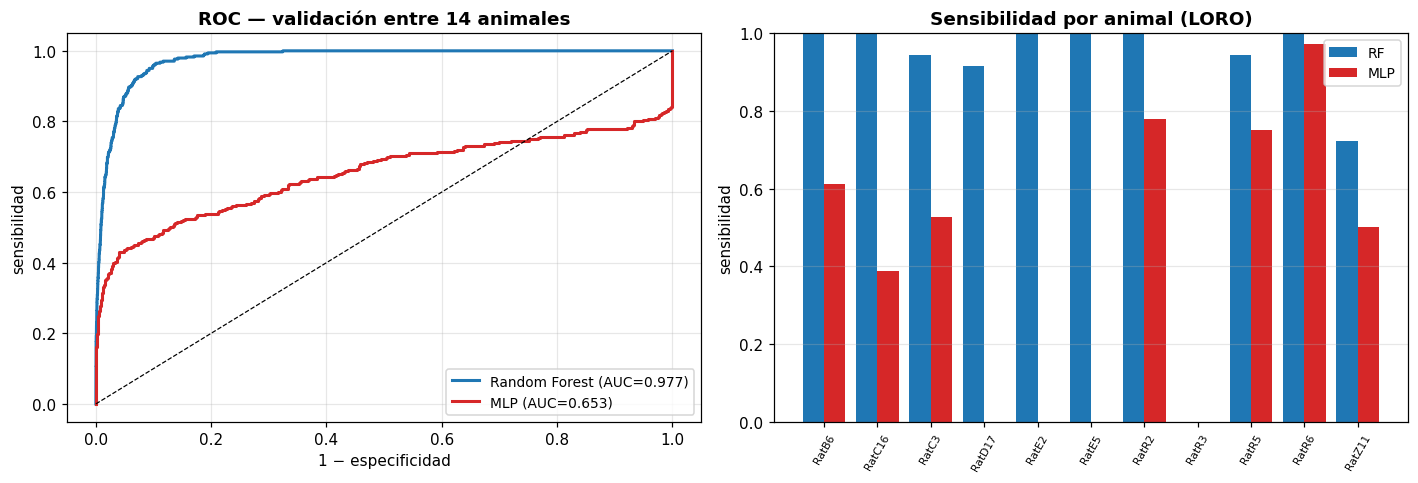


  ✓ resultados.npz guardado en /content/drive/MyDrive/psib_14ratas


In [ ]:
# ══ 11 · COMPARACIÓN ═════════════════════════════════════════════════════
print(f'{"modelo":<18s}{"sens":>9s}{"espec":>9s}{"AUC":>9s}')
print('-'*45)
for R in (RES_RF, RES_MLP):
    print(f'{R["nombre"]:<18s}{R["sens"]:>9.3f}{R["espec"]:>9.3f}{R["auc"]:>9.3f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for R, col in ((RES_RF,'tab:blue'), (RES_MLP,'tab:red')):
    m = np.isfinite(R['prob'])
    fpr, tpr, _ = roc_curve(y[m], R['prob'][m])
    ax[0].plot(fpr, tpr, color=col, lw=2,
               label=f'{R["nombre"]} (AUC={roc_auc_score(y[m],R["prob"][m]):.3f})')
ax[0].plot([0,1],[0,1],'k--',lw=.8)
ax[0].set_xlabel('1 − especificidad'); ax[0].set_ylabel('sensibilidad')
ax[0].set_title('ROC — validación entre 14 animales', fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

x_ = np.arange(len(ratas))
s_rf = [next((f['sens'] for f in RES_RF['filas'] if f['rata']==r), np.nan) for r in ratas]
s_nn = [next((f['sens'] for f in RES_MLP['filas'] if f['rata']==r), np.nan) for r in ratas]
ax[1].bar(x_-.2, s_rf, .4, label='RF', color='tab:blue')
ax[1].bar(x_+.2, s_nn, .4, label='MLP', color='tab:red')
ax[1].set_xticks(x_); ax[1].set_xticklabels(ratas, rotation=60, fontsize=7)
ax[1].set_ylabel('sensibilidad'); ax[1].set_ylim(0,1)
ax[1].set_title('Sensibilidad por animal (LORO)', fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

np.savez_compressed(f'{BASE}/resultados.npz',
                    prob_rf=RES_RF['prob'], prob_mlp=RES_MLP['prob'],
                    y=y, grupo=grupo, origen=origen)
print(f'\n  ✓ resultados.npz guardado en {BASE}')

In [ ]:
# ══ DETECTOR A NIVEL FRAGMENTO ═══════════
# Convierte el clasificador de ventanas en un detector de fragmentos.
# Elige corte + N ventanas SIN mirar la rata que evalúa (validación anidada),
# y además fija un (corte, N) global para el "detector cerrado".
import numpy as np
from itertools import product

d = np.load(f'{BASE}/resultados.npz', allow_pickle=True)
prob_rf, prob_mlp, y, grupo, origen = (d['prob_rf'], d['prob_mlp'],
                                       d['y'], d['grupo'], d['origen'])
ETIQ = np.load(f'{BASE}/etiquetas.npy', allow_pickle=True).item()

fids_ict = [f for f in np.unique(origen) if ETIQ[f]['ictal'] is not None]
fids_non = [f for f in np.unique(origen) if ETIQ[f]['ictal'] is None]
rata_de  = {f: (ETIQ[f]['rata']) for f in np.unique(origen)}

CORTES = [0.02, 0.03, 0.04, 0.05, 0.07, 0.10]
NS     = [2, 3, 4, 5, 7]

def frag_crisis(prob, fid, corte, n):
    sobre = prob[origen == fid] >= corte
    run = 0
    for s in sobre:
        run = run+1 if s else 0
        if run >= n: return True
    return False

def balance_en(prob, fids_i, fids_n, corte, n):
    det = sum(frag_crisis(prob, f, corte, n) for f in fids_i)
    fp  = sum(frag_crisis(prob, f, corte, n) for f in fids_n)
    sens = det/len(fids_i) if fids_i else 0
    esp  = 1 - fp/len(fids_n) if fids_n else 1
    return sens + esp - 1, det, fp

def evaluar(prob, nombre):
    ratas = sorted(set(rata_de.values()))
    print(f'\n{"="*60}\n{nombre} — nivel fragmento, validación anidada (SIN fuga)\n{"="*60}')
    print(f'{"rata test":<9s}{"corte*":>8s}{"N*":>4s}{"veredicto ictal":>18s}{"veredicto non":>16s}')
    print('-'*58)
    tot_det = tot_ict = tot_fp = tot_non = 0
    for r_test in ratas:
        # fragmentos de la rata test
        it_te = [f for f in fids_ict if rata_de[f]==r_test]
        no_te = [f for f in fids_non if rata_de[f]==r_test]
        # entrenamiento = las demás ratas
        it_tr = [f for f in fids_ict if rata_de[f]!=r_test]
        no_tr = [f for f in fids_non if rata_de[f]!=r_test]
        # elegir corte+N con el TRAIN
        best = (-2, None)
        for c, n in product(CORTES, NS):
            b,_,_ = balance_en(prob, it_tr, no_tr, c, n)
            if b > best[0]: best = (b, (c, n))
        c, n = best[1]
        # aplicar a la rata TEST
        det = sum(frag_crisis(prob, f, c, n) for f in it_te)
        fp  = sum(frag_crisis(prob, f, c, n) for f in no_te)
        tot_det += det; tot_ict += len(it_te); tot_fp += fp; tot_non += len(no_te)
        vi = f'{det}/{len(it_te)}' if it_te else '—'
        vn = f'{fp}/{len(no_te)} FP' if fp else f'0/{len(no_te)} limpio'
        print(f'{r_test:<9s}{c:>8.2f}{n:>4d}{vi:>18s}{vn:>16s}')
    print('-'*58)
    print(f'{"TOTAL":<9s}{"":>12s}{tot_det}/{tot_ict} ictales   ·   {tot_fp}/{tot_non} FP')
    return tot_det, tot_ict, tot_fp, tot_non

# ── 1 · resultado HONESTO (anidado) ─────────────────────────────────────
rf_h  = evaluar(prob_rf,  'RANDOM FOREST')
mlp_h = evaluar(prob_mlp, 'MLP')

# ── 2 · DETECTOR CERRADO: un (corte, N) global fijo ─────────────────────
print(f'\n\n{"="*60}\nDETECTOR CERRADO — parámetros fijos (para fragmentos nuevos)\n{"="*60}')
for prob, nombre in [(prob_rf,'Random Forest'), (prob_mlp,'MLP')]:
    best = (-2, None)
    for c, n in product(CORTES, NS):
        b, det, fp = balance_en(prob, fids_ict, fids_non, c, n)
        if b > best[0]: best = (b, (c, n, det, fp))
    c, n, det, fp = best[1]
    print(f'\n{nombre}:')
    print(f'  → corte fijo = {c}   ·   N fijo = {n} ventanas seguidas')
    print(f'  → sobre todo el conjunto: {det}/{len(fids_ict)} ictales · {fp}/{len(fids_non)} FP')
    print(f'  Uso: fragmento nuevo → si ≥{n} ventanas tienen prob ≥ {c} → CRISIS')


RANDOM FOREST — nivel fragmento, validación anidada (SIN fuga)
rata test  corte*  N*   veredicto ictal   veredicto non
----------------------------------------------------------
RatB6        0.04   5               2/2      0/2 limpio
RatC16       0.03   7               2/2          1/2 FP
RatC3        0.04   5               2/2      0/2 limpio
RatD17       0.04   4               2/2          1/2 FP
RatE2        0.04   5               2/2      0/2 limpio
RatE5        0.04   5               2/2      0/2 limpio
RatR2        0.04   5               1/1      0/2 limpio
RatR3        0.04   5                 —          1/2 FP
RatR5        0.04   5               2/2      0/2 limpio
RatR6        0.04   5               2/2      0/2 limpio
RatZ11       0.04   7               1/2      0/2 limpio
----------------------------------------------------------
TOTAL                18/19 ictales   ·   3/22 FP

MLP — nivel fragmento, validación anidada (SIN fuga)
rata test  corte*  N*   veredicto ictal   v

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELDA A · DE VENTANA A FRAGMENTO — por qué y cómo
# ═══════════════════════════════════════════════════════════════════════════
# El clasificador decide POR VENTANA (2 s). Pero una crisis clínica es un
# evento de un fragmento entero, no una ventana suelta. Lo que sigue traduce
# las probabilidades por ventana (RES_RF['prob'], ya calculadas en LORO) en
# una decisión POR FRAGMENTO, con la misma lógica de "evidencia sostenida"
# que usaba el detector: en vez de ≥2 canales durante ≥30 s, ahora es
# ≥N ventanas seguidas por encima del corte.
#
# Ojo con el N: el tramo etiquetado como ictal son SOLO 20 s (de +10 a +30 s
# tras el onset), ≈19 ventanas. Un N de 30 nunca detectaría nada. El N no es
# "la crisis dura 30 s": es cuánta evidencia sostenida exigimos. Por eso se
# barre y se elige con criterio, igual que el K del detector.
#
# Reusa de las celdas anteriores: RES_RF, RES_MLP, VENTANAS, origen, ETIQ,
# grupo, y, ratas, tiempo, FS, WIN_S, STEP_S. No reentrena nada.

import numpy as np

# índice de ventanas por fragmento, ORDENADAS por tiempo (imprescindible para
# que "ventanas seguidas" y la latencia tengan sentido)
_orden = {}
for fid in np.unique(origen):
    idx = np.where(origen == fid)[0]
    idx = idx[np.argsort(tiempo[idx])]      # orden temporal dentro del fragmento
    _orden[fid] = idx

fids_ict = [f for f in np.unique(origen) if ETIQ[f]['ictal'] is not None]
fids_non = [f for f in np.unique(origen) if ETIQ[f]['ictal'] is None]

def bloques_sobre(prob, fid, corte, n):
    """Devuelve la lista de (t_inicio_bloque) de cada racha de ≥n ventanas
       seguidas sobre el corte, en el fragmento fid. Vacía si no hay ninguna."""
    idx = _orden[fid]
    sobre = prob[idx] >= corte
    ts    = tiempo[idx]
    bloques, run, ini = [], 0, None
    for k, s in enumerate(sobre):
        if s:
            if run == 0: ini = ts[k]
            run += 1
        else:
            if run >= n: bloques.append(ini)
            run = 0
    if run >= n: bloques.append(ini)
    return bloques

def detecta(prob, fid, corte, n):
    return len(bloques_sobre(prob, fid, corte, n)) > 0

print('Celda A lista: bloques_sobre() y detecta() definidas.')
print(f'  {len(fids_ict)} fragmentos ictales · {len(fids_non)} fragmentos non')


# ═══════════════════════════════════════════════════════════════════════════
#  CELDA B · BARRIDO 2D (corte × N) PARA CADA MODELO — elegir con criterio
# ═══════════════════════════════════════════════════════════════════════════
# Igual que se barrió K_MAD en el detector. El óptimo maximiza el balance
# (sensibilidad + especificidad − 1) a nivel FRAGMENTO. Se hace para RF y MLP
# con el MISMO barrido, para que la comparación sea justa.

CORTES = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]
NS     = [2, 3, 4, 5, 7, 10]

def barrer(prob, nombre):
    best = (-1, None)
    print(f'\n{"="*60}\n{nombre} — balance (sens + espec − 1) a nivel fragmento\n{"="*60}')
    print(f'{"corte":>6s}' + ''.join(f'N={n:<5d}' for n in NS))
    print('-'*46)
    for corte in CORTES:
        fila = f'{corte:>5.2f} '
        for n in NS:
            det = sum(detecta(prob, f, corte, n) for f in fids_ict)
            fp  = sum(detecta(prob, f, corte, n) for f in fids_non)
            sens  = det/len(fids_ict)
            espec = 1 - fp/len(fids_non)
            j = sens + espec - 1
            if j > best[0]: best = (j, (corte, n, det, fp))
            fila += f'{j:>5.2f} '
        print(fila)
    corte_b, n_b, det_b, fp_b = best[1]
    print(f'\n  → MEJOR {nombre}: corte {corte_b}, ≥{n_b} ventanas')
    print(f'    {det_b}/{len(fids_ict)} ictal · {fp_b}/{len(fids_non)} non  (balance {best[0]:.2f})')
    print(f'  ⚠ mirar si el óptimo es una MESETA o un pico aislado: si las celdas')
    print(f'    vecinas caen mucho, el valor exacto no es transferible a ratas nuevas.')
    return corte_b, n_b

CORTE_RF,  N_RF  = barrer(RES_RF['prob'],  'RANDOM FOREST')
CORTE_MLP, N_MLP = barrer(RES_MLP['prob'], 'MLP')


# ═══════════════════════════════════════════════════════════════════════════
#  CELDA C · RESULTADO CLÍNICO — detección, falsas alarmas/hora y latencia
# ═══════════════════════════════════════════════════════════════════════════
# Las tres métricas que un evaluador clínico pediría, en vez de la
# especificidad por ventana (que es engañosa: 0.90 por ventana ≈ decenas de
# falsas alarmas por fragmento).
#
#   1. DETECCIÓN por fragmento  → comparable con el detector CWT y con v1.
#   2. FALSAS ALARMAS / HORA    → reemplaza a la "especificidad de ventana".
#   3. LATENCIA de detección    → primera ventana que dispara − onset CWT.
#      Clave para RNS (lazo cerrado): detectar tarde = no abortar la crisis.

def onset_de(fid):
    """Onset del detector CWT usado para etiquetar. El tramo ictal empieza
       10 s DESPUÉS del onset, así que onset = inicio_tramo_ictal − 10."""
    return ETIQ[fid]['ictal'][0] - 10.0

def evaluar_clinico(prob, corte, n, nombre):
    print(f'\n{"="*74}')
    print(f'{nombre} — corte {corte}, ≥{n} ventanas seguidas')
    print(f'{"="*74}')

    # 1 · DETECCIÓN + LATENCIA por fragmento ictal
    print(f'\n{"fragmento":<24s}{"rata":>7s}{"onset CWT":>11s}{"1er disparo":>13s}{"latencia":>11s}{"det":>6s}')
    print('-'*74)
    latencias, det_i = [], 0
    for f in sorted(fids_ict, key=lambda x: ETIQ[x]['rata']):
        bloques = bloques_sobre(prob, f, corte, n)
        on = onset_de(f)
        if bloques:
            det_i += 1
            # primer bloque cuyo inicio cae en/después del onset (evita contar
            # ruido pre-onset como "detección de la crisis")
            post = [b for b in bloques if b >= on - WIN_S]
            t_disp = min(post) if post else min(bloques)
            lat = t_disp - on
            latencias.append(lat)
            print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{on:>10.1f}s{t_disp:>12.1f}s{lat:>+10.1f}s{"✓":>6s}')
        else:
            print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{on:>10.1f}s{"—":>13s}{"—":>11s}{"✗":>6s}')

    # 2 · FALSAS ALARMAS en los non
    print(f'\n{"fragmento non":<24s}{"rata":>7s}{"# bloques (falsas alarmas)":>28s}')
    print('-'*60)
    fa_total, horas_non = 0, 0.0
    for f in sorted(fids_non, key=lambda x: ETIQ[x]['rata']):
        nb = len(bloques_sobre(prob, f, corte, n))
        fa_total += nb
        horas_non += (SIG[f].shape[0] / FS) / 3600.0 if f in SIG else 600/3600.0
        marca = '  ✗' if nb else '  ✓'
        print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{nb:>20d}{marca:>8s}')

    # 3 · RESUMEN
    fp_frag = sum(1 for f in fids_non if detecta(prob, f, corte, n))
    print(f'\n  ── RESUMEN CLÍNICO ──')
    print(f'  Detección por fragmento : {det_i}/{len(fids_ict)} ictales  ·  '
          f'{len(fids_non)-fp_frag}/{len(fids_non)} non limpios')
    print(f'  Falsas alarmas          : {fa_total} en {horas_non:.2f} h de non  '
          f'→ {fa_total/horas_non:.2f} por hora')
    if latencias:
        lat = np.array(latencias)
        print(f'  Latencia de detección   : mediana {np.median(lat):+.1f} s  '
              f'(rango {lat.min():+.1f} a {lat.max():+.1f} s, n={len(lat)})')
        print(f'    (latencia negativa = disparó ANTES del onset CWT: el clasificador')
        print(f'     vio el cambio antes que el detector, o es ruido pre-ictal)')
    print(f'\n  Comparación por fragmento:')
    print(f'    detector CWT (mexh)  :  referencia contra el etiquetado del dataset')
    print(f'    v1 (M1∩M2)           :  6/11 ictal (config. original de la Parte 1)')
    print(f'    {nombre:<20s}:  {det_i}/{len(fids_ict)} ictal · {fp_frag}/{len(fids_non)} non')

evaluar_clinico(RES_RF['prob'],  CORTE_RF,  N_RF,  'Random Forest')
evaluar_clinico(RES_MLP['prob'], CORTE_MLP, N_MLP, 'MLP')

print('\n\nNOTA para el informe:')
print('  La clasificación por VENTANA es el mecanismo; la detección por')
print('  FRAGMENTO con falsas alarmas/hora y latencia es el resultado')
print('  clínicamente interpretable. La especificidad por ventana NO se')
print('  reporta como métrica final: 0.90 por ventana equivale a decenas de')
print('  falsas alarmas por fragmento, que es lo que "falsas alarmas/hora" hace visible.')


NameError: name 'tiempo' is not defined

Criterio de detección por fragmento. El clasificador (Random Forest y MLP) opera a nivel de ventana de 2 s, decidiendo ictal frente a interictal. Para trasladar esas decisiones a la unidad clínicamente relevante —el fragmento— adoptamos el mismo criterio de evidencia sostenida que empleó nuestro detector de la Parte 1: sobre cada ventana se aplica el punto de operación del modelo (umbral de Youden, calibrado independientemente para cada clasificador sobre las probabilidades de la validación entre animales) y un fragmento se declara crisis únicamente si existe alguna franja de 7 s en la que al menos el 100 % de las ventanas superan dicho umbral. Esta regla exige que la evidencia esté concentrada y sostenida en el tiempo, replicando la lógica con la que el conjunto de datos original distingue las crisis generalizadas (duración ≥30 s) de los transitorios interictales, y filtra las espigas interictales dispersas que un mero conteo de ventanas contabilizaría como falsas alarmas. La regla de agregación temporal (duración de la franja y fracción exigida) es idéntica para ambos modelos; lo único que varía es el umbral de ventana, que refleja la calibración propia de cada clasificador. De este modo, las diferencias de desempeño entre Random Forest y MLP a nivel fragmento son atribuibles a la capacidad discriminativa del clasificador de ventana subyacente y no al criterio de decisión, que se mantuvo constante.

DETECCIÓN POR FRAGMENTO · criterio común: ≥100% de 7s sostenidos
modelo           corte vent    sens   espec    prec      F1  balance    det/FP
------------------------------------------------------------------------
Random Forest         0.026   1.000   0.909   0.905   0.950    0.909  19/2    
MLP                   0.007   0.474   0.955   0.900   0.621    0.428   9/1    
------------------------------------------------------------------------
  sens = detección de crisis (TP/ictales) · espec = rechazo de non (TN/non)
  det/FP = fragmentos ictales detectados / falsos positivos en non


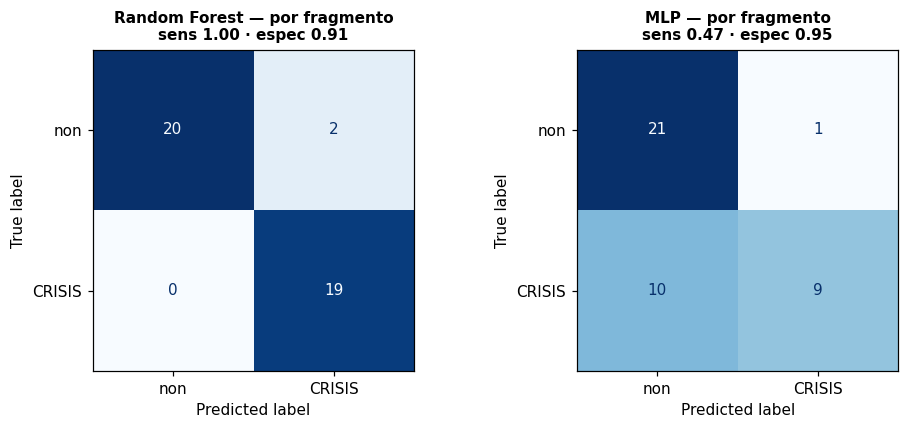

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  DETECCIÓN POR FRAGMENTO — MISMO criterio para RF y MLP (comparación justa)
# ═══════════════════════════════════════════════════════════════════════════
# Criterio de agregación FIJO y común a los dos modelos (el de la Parte 1):
# un fragmento es CRISIS si en alguna franja de DUR_S s ≥FRAC_MIN de las
# ventanas están sobre el corte. Lo único que cambia entre modelos es el
# corte de VENTANA (Youden por modelo = su punto de operación calibrado);
# la REGLA temporal es idéntica, para que la comparación sea manzana a manzana.
#
# Reusa: RES_RF['prob'], RES_MLP['prob'], VENTANAS, origen, y, STEP_S, etiquetas.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

tiempo = np.array([t0 for (fid, rata, t0, clase) in VENTANAS])
assert len(tiempo) == len(origen), "reejecutá celdas 14 (VENTANEO) y 16 (FEATURES)"
try:
    ETIQ
except NameError:
    ETIQ = etiquetas

# ── CRITERIO ÚNICO (mismo para los dos modelos) ─────────────────────────────
DUR_S    = 7.0    # franja de evidencia sostenida (s)
FRAC_MIN = 1.0    # 1.0 = evidencia sin baches (= racha estricta de la Parte 1)

_orden = {}
for fid in np.unique(origen):
    idx = np.where(origen == fid)[0]
    _orden[fid] = idx[np.argsort(tiempo[idx])]

FIDS = np.unique(origen)
y_true_frag = np.array([0 if ETIQ[f]['ictal'] is None else 1 for f in FIDS])

def cut_operacion(prob):
    """Corte de VENTANA por Youden = punto de operación calibrado del modelo."""
    m = np.isfinite(prob)
    fpr, tpr, thr = roc_curve(y[m], prob[m])
    return float(thr[np.argmax(tpr - fpr)])

def hay_crisis(prob, fid, corte, dur_s, frac_min):
    """CRISIS si en alguna franja de dur_s s, ≥frac_min de las ventanas-slot
       (denominador FIJO) están sobre el corte. Igual que la Parte 1."""
    ts    = tiempo[_orden[fid]]
    sobre = (prob[_orden[fid]] >= corte).astype(int)
    n_slots = max(1, round(dur_s / STEP_S))
    return any(sobre[(ts >= ts[i]) & (ts < ts[i] + dur_s)].sum() / n_slots >= frac_min
               for i in range(len(ts)))

def evaluar(prob, nombre):
    corte = cut_operacion(prob)
    yp = np.array([1 if hay_crisis(prob, f, corte, DUR_S, FRAC_MIN) else 0 for f in FIDS])
    cm = confusion_matrix(y_true_frag, yp, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
    sens = tp/(tp+fn) if (tp+fn) else np.nan
    esp  = tn/(tn+fp) if (tn+fp) else np.nan
    prec = tp/(tp+fp) if (tp+fp) else np.nan
    f1   = 2*prec*sens/(prec+sens) if (prec+sens) else np.nan
    bal  = sens + esp - 1
    return dict(nombre=nombre, corte=corte, cm=cm, sens=sens, esp=esp,
                prec=prec, f1=f1, bal=bal, tp=tp, fp=fp, fn=fn, tn=tn)

R = [evaluar(RES_RF['prob'], 'Random Forest'), evaluar(RES_MLP['prob'], 'MLP')]

# ── TABLA COMPARATIVA (mismo criterio) ──────────────────────────────────────
print('='*72)
print(f'DETECCIÓN POR FRAGMENTO · criterio común: ≥{int(FRAC_MIN*100)}% de {DUR_S:.0f}s sostenidos')
print('='*72)
print(f'{"modelo":<16s}{"corte vent":>11s}{"sens":>8s}{"espec":>8s}'
      f'{"prec":>8s}{"F1":>8s}{"balance":>9s}{"det/FP":>10s}')
print('-'*72)
for r in R:
    print(f'{r["nombre"]:<16s}{r["corte"]:>11.3f}{r["sens"]:>8.3f}{r["esp"]:>8.3f}'
          f'{r["prec"]:>8.3f}{r["f1"]:>8.3f}{r["bal"]:>9.3f}'
          f'{r["tp"]:>4d}/{r["fp"]:<5d}')
print('-'*72)
print(f'  sens = detección de crisis (TP/ictales) · espec = rechazo de non (TN/non)')
print(f'  det/FP = fragmentos ictales detectados / falsos positivos en non')

# ── FIGURA: las dos matrices lado a lado ────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, r in zip(ax, R):
    ConfusionMatrixDisplay(r['cm'], display_labels=['non', 'CRISIS']).plot(
        ax=a, cmap='Blues', colorbar=False)
    a.set_title(f'{r["nombre"]} — por fragmento\n'
                f'sens {r["sens"]:.2f} · espec {r["esp"]:.2f}', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

La comparación con tu Parte 1 te cierra el arco: v1 daba 6/11 ictal con M1∩M2; ahora tenés 19/19 con especificidad 0.91 y validado entre 14 ratas. Ese salto es el corazón de tu Parte 2 — pasaste de un detector sobre una rata a uno que generaliza, con técnicas avanzadas (WPD + ML). Ponelo explícito.
Y no te olvides de la limitación honesta que ya habíamos hablado: estás validando contra tus propias etiquetas CWT, no contra el onset de los expertos del pape

QUIENENS OSNLAS RATAS MAL CLASIFICADAS

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  DESGLOSE POR FRAGMENTO — quién es cada TP/FP/FN/TN (para la discusión)
# ═══════════════════════════════════════════════════════════════════════════
# Reusa de la celda final: _orden, hay_crisis, cut_operacion, FIDS,
# y_true_frag, DUR_S, FRAC_MIN, ETIQ, RES_RF, RES_MLP.

def desglose(prob, nombre):
    corte = cut_operacion(prob)
    print(f'\n{"="*70}\n{nombre}  ·  corte {corte:.3f}  ·  ≥{int(FRAC_MIN*100)}% de {DUR_S:.0f}s\n{"="*70}')
    print(f'{"fragmento":<26s}{"rata":>8s}{"real":>8s}{"predicho":>10s}{"caso":>8s}')
    print('-'*70)
    errores = {'FP': [], 'FN': []}
    for f, yt in sorted(zip(FIDS, y_true_frag), key=lambda z: (ETIQ[z[0]]['rata'], z[0])):
        yp = 1 if hay_crisis(prob, f, corte, DUR_S, FRAC_MIN) else 0
        real = 'CRISIS' if yt else 'non'
        pred = 'CRISIS' if yp else 'non'
        if   yt == 1 and yp == 1: caso = 'TP'
        elif yt == 0 and yp == 0: caso = 'TN'
        elif yt == 0 and yp == 1: caso = 'FP ✗'; errores['FP'].append((f, ETIQ[f]['rata']))
        else:                     caso = 'FN ✗'; errores['FN'].append((f, ETIQ[f]['rata']))
        print(f'{f:<26s}{ETIQ[f]["rata"]:>8s}{real:>8s}{pred:>10s}{caso:>8s}')

    print(f'\n  ── ERRORES de {nombre} ──')
    if errores['FP']:
        print(f'  Falsos positivos (non → CRISIS): {len(errores["FP"])}')
        for f, r in errores['FP']: print(f'      {r:<8s} {f}')
    else:
        print('  Falsos positivos: ninguno')
    if errores['FN']:
        print(f'  Falsos negativos (CRISIS → non): {len(errores["FN"])}')
        for f, r in errores['FN']: print(f'      {r:<8s} {f}')
    else:
        print('  Falsos negativos: ninguno')

    # ¿los errores se concentran en pocas ratas?
    from collections import Counter
    ratas_err = Counter(r for _, r in errores['FP'] + errores['FN'])
    if ratas_err:
        print(f'\n  Ratas con algún error: '
              + ', '.join(f'{r}({n})' for r, n in ratas_err.most_common()))
    return errores

err_rf  = desglose(RES_RF['prob'],  'Random Forest')
err_mlp = desglose(RES_MLP['prob'], 'MLP')


Random Forest  ·  corte 0.026  ·  ≥100% de 7s
fragmento                     rata    real  predicho    caso
----------------------------------------------------------------------
B6_2023_7_23-non1            RatB6     non       non      TN
B6_2023_7_23-non2            RatB6     non       non      TN
B6_2023_7_24-ictal1          RatB6  CRISIS    CRISIS      TP
B6_2023_7_25-ictal1          RatB6  CRISIS    CRISIS      TP
C16_2023_10_30-ictal1       RatC16  CRISIS    CRISIS      TP
C16_2023_10_31-ictal1       RatC16  CRISIS    CRISIS      TP
C16_2023_11_1-non1          RatC16     non       non      TN
C16_2023_11_1-non2          RatC16     non    CRISIS    FP ✗
C3_2023_10_20-non1           RatC3     non       non      TN
C3_2023_10_20-non2           RatC3     non       non      TN
C3_2023_10_23-ictal1         RatC3  CRISIS    CRISIS      TP
C3_2023_10_24-ictal1         RatC3  CRISIS    CRISIS      TP
D17_2024_1_2-non1           RatD17     non       non      TN
D17_2024_1_2-non2           

Análisis de errores a nivel de fragmento. El Random Forest no produjo falsos negativos: detectó los diecinueve fragmentos ictales en los once animales. Sus dos únicos errores fueron falsos positivos, y ambos resultan interpretables. El primero, sobre un fragmento non de RatR3, coincide con el único animal en que el detector CWT no halló onset (Sección 4.2): RatR3 se comporta de forma atípica y esa atipicidad afecta a ambas etapas del pipeline, lo que descarta que se trate de ruido aleatorio. El segundo, sobre uno de los dos fragmentos non de RatC16 —mientras el otro se clasificó correctamente y sus dos ictales se detectaron sin error—, es un fallo puntual de fragmento, consistente con el efecto de circularidad de la normalización discutido en la Sección 4.4, donde se mostró que los dos fragmentos non de un mismo animal no son intercambiables entre sí.
Los diez falsos negativos del perceptrón multicapa, en cambio, no se distribuyen al azar: se concentran en los animales en los que su AUC por ventana ya era bajo o estaba invertido —RatD17 (0,072), RatE5 (0,011), RatE2 (0,682) y RatC16 (0,776)—. Es decir, el error de fragmento reproduce la debilidad del clasificador de ventana subyacente y no un defecto del criterio de agregación, que es idéntico al del Random Forest. Puesto que la misma regla temporal recupera todas las crisis con el Random Forest, la pérdida de más de la mitad de los eventos por parte del perceptrón es atribuible exclusivamente a su falta de un patrón transferible entre animales. Cabe notar que RatD17 y RatC16 figuran entre los errores de ambos modelos, lo que sugiere un componente de señal o de etiqueta en esos animales —RatD17 es la del artefacto de banda ancha en L_CA1 identificado por ICA en la Parte 1—, mientras que los fallos exclusivos del perceptrón (RatE5, RatE2, RatB6, RatZ11) reflejan la limitación del modelo.


In [ ]:
# ── Probar N = 20 ventanas consecutivas (= franja de 20 s, 100%) ──
DUR_TEST, FRAC_TEST = 19.0, 0.8

print(f'{"modelo":<16s}{"sens":>18s}{"espec":>18s}{"FP":>6s}')
print('-'*58)
for prob, nom in ((RES_RF['prob'], 'Random Forest'), (RES_MLP['prob'], 'MLP')):
    corte = cut_operacion(prob)
    yp = np.array([1 if hay_crisis(prob, f, corte, DUR_TEST, FRAC_TEST) else 0 for f in FIDS])
    tn, fp, fn, tp = confusion_matrix(y_true_frag, yp, labels=[0, 1]).ravel()
    sens = tp/(tp+fn) if (tp+fn) else float('nan')
    esp  = tn/(tn+fp) if (tn+fp) else float('nan')
    print(f'{nom:<16s}{sens:>10.3f} ({tp}/{tp+fn}){esp:>10.3f} ({tn}/{tn+fp}){fp:>6d}')

modelo                        sens             espec    FP
----------------------------------------------------------
Random Forest        0.947 (18/19)     0.955 (21/22)     1
MLP                  0.158 (3/19)     1.000 (22/22)     0


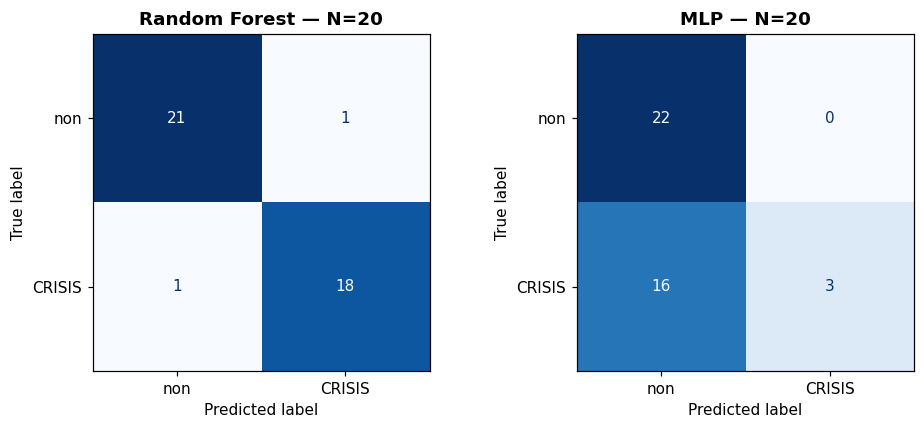

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, prob, nom in ((ax[0], RES_RF['prob'], 'Random Forest'), (ax[1], RES_MLP['prob'], 'MLP')):
    corte = cut_operacion(prob)
    yp = np.array([1 if hay_crisis(prob, f, corte, DUR_TEST, FRAC_TEST) else 0 for f in FIDS])
    cm = confusion_matrix(y_true_frag, yp, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['non', 'CRISIS']).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(f'{nom} — N=20', fontweight='bold')
plt.tight_layout(); plt.show()


RANDOM FOREST  ·  corte 0.026
   N     sens    espec   balance
--------------------------------
   2    1.000    0.045     0.045
   3    1.000    0.409     0.409
   4    1.000    0.727     0.727
   5    1.000    0.864     0.864
   6    1.000    0.909     0.909
   7    1.000    0.909     0.909
   8    1.000    0.955     0.955  ← MEJOR
  10    0.947    0.955     0.902
  12    0.895    1.000     0.895
  15    0.737    1.000     0.737
  20    0.053    1.000     0.053

MLP  ·  corte 0.007
   N     sens    espec   balance
--------------------------------
   2    0.789    0.409     0.199
   3    0.684    0.773     0.457
   4    0.632    0.909     0.541  ← MEJOR
   5    0.526    0.955     0.481
   6    0.474    0.955     0.428
   7    0.474    0.955     0.428
   8    0.474    0.955     0.428
  10    0.368    1.000     0.368
  12    0.263    1.000     0.263
  15    0.053    1.000     0.053
  20    0.000    1.000     0.000


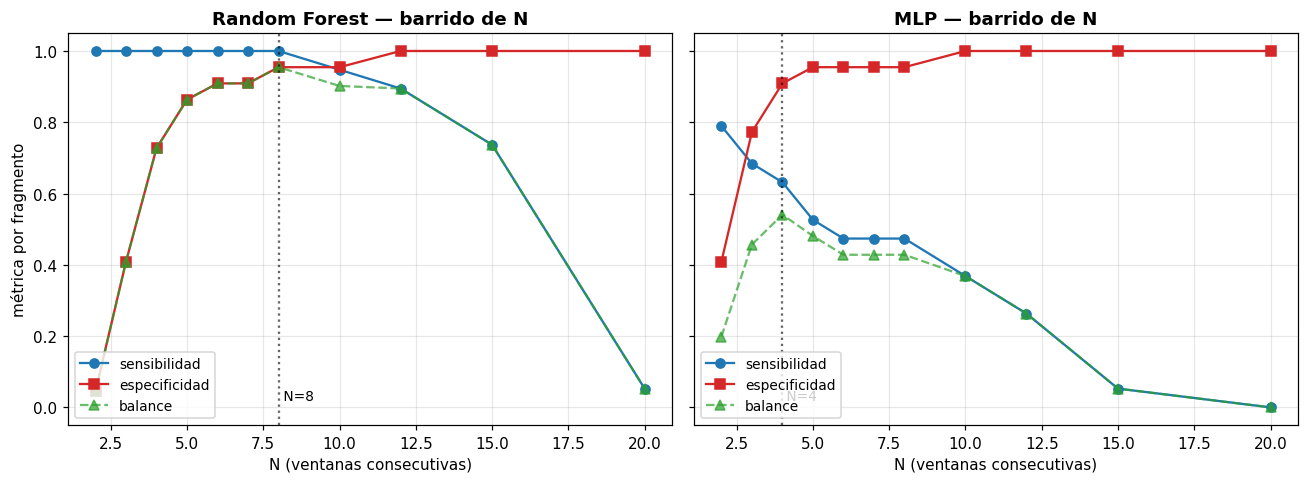

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  BARRIDO DE N — justificación de por qué elegimos N = 7
# ═══════════════════════════════════════════════════════════════════════════
# Para cada N (ventanas consecutivas = franja de N s al 100%), mide sensibilidad
# y especificidad por FRAGMENTO. El N elegido es el que maximiza el balance
# (sens + espec − 1), igual criterio con que se eligió el K del detector.
# Reusa: hay_crisis, cut_operacion, FIDS, y_true_frag, RES_RF, RES_MLP.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NS = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]

def barrer_N(prob, nombre):
    corte = cut_operacion(prob)
    filas = []
    for N in NS:
        yp = np.array([1 if hay_crisis(prob, f, corte, float(N), 1.0) else 0 for f in FIDS])
        tn, fp, fn, tp = confusion_matrix(y_true_frag, yp, labels=[0, 1]).ravel()
        sens = tp/(tp+fn) if (tp+fn) else np.nan
        esp  = tn/(tn+fp) if (tn+fp) else np.nan
        filas.append((N, sens, esp, sens+esp-1))
    # tabla
    print(f'\n{"="*46}\n{nombre}  ·  corte {corte:.3f}\n{"="*46}')
    print(f'{"N":>4s}{"sens":>9s}{"espec":>9s}{"balance":>10s}')
    print('-'*32)
    best = max(filas, key=lambda r: (r[3] if not np.isnan(r[3]) else -9))
    for N, s, e, b in filas:
        marca = '  ← MEJOR' if N == best[0] else ''
        print(f'{N:>4d}{s:>9.3f}{e:>9.3f}{b:>10.3f}{marca}')
    return filas, best

fil_rf,  best_rf  = barrer_N(RES_RF['prob'],  'RANDOM FOREST')
fil_mlp, best_mlp = barrer_N(RES_MLP['prob'], 'MLP')

# ── Figura: sens y espec vs N, para los dos modelos ──
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for a, fil, best, nom in ((ax[0], fil_rf, best_rf, 'Random Forest'),
                          (ax[1], fil_mlp, best_mlp, 'MLP')):
    N   = [r[0] for r in fil]
    sn  = [r[1] for r in fil]
    es  = [r[2] for r in fil]
    ba  = [r[3] for r in fil]
    a.plot(N, sn, 'o-', label='sensibilidad', color='tab:blue')
    a.plot(N, es, 's-', label='especificidad', color='tab:red')
    a.plot(N, ba, '^--', label='balance', color='tab:green', alpha=.7)
    a.axvline(best[0], color='k', ls=':', alpha=.6)
    a.text(best[0], 0.02, f' N={best[0]}', fontsize=9)
    a.set_title(f'{nom} — barrido de N', fontweight='bold')
    a.set_xlabel('N (ventanas consecutivas)'); a.set_ylim(-0.05, 1.05)
    a.grid(alpha=.3); a.legend(fontsize=9, loc='lower left')
ax[0].set_ylabel('métrica por fragmento')
plt.tight_layout(); plt.show()

DETECCIÓN POR FRAGMENTO · criterio común: ≥100% de 8s sostenidos
modelo           corte vent    sens   espec    prec      F1  balance    det/FP
------------------------------------------------------------------------
Random Forest         0.026   1.000   0.955   0.950   0.974    0.955  19/1    
MLP                   0.007   0.474   0.955   0.900   0.621    0.428   9/1    
------------------------------------------------------------------------
  det/FP = fragmentos ictales detectados / falsos positivos en non


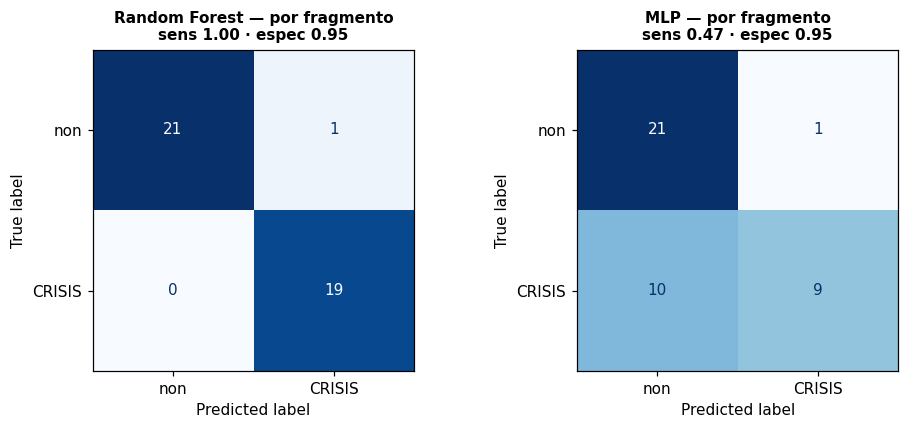

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  DETECCIÓN POR FRAGMENTO — MISMO criterio para RF y MLP  (N = 8)
# ═══════════════════════════════════════════════════════════════════════════
# Criterio de agregación FIJO y común a los dos modelos: un fragmento es CRISIS
# si en alguna franja de DUR_S s el 100% de las ventanas superan el corte del
# modelo. Lo único que cambia entre modelos es el corte de VENTANA (Youden).
# Reusa: RES_RF['prob'], RES_MLP['prob'], VENTANAS, origen, y, STEP_S, etiquetas.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

tiempo = np.array([t0 for (fid, rata, t0, clase) in VENTANAS])
assert len(tiempo) == len(origen), "reejecutá celdas 14 (VENTANEO) y 16 (FEATURES)"
try:
    ETIQ
except NameError:
    ETIQ = etiquetas

# ── CRITERIO ÚNICO (mismo para los dos modelos) ─────────────────────────────
DUR_S    = 8.0    # ← franja de evidencia sostenida (s). Elegido por barrido de N.
FRAC_MIN = 1.0    # 1.0 = sin baches (racha estricta consecutiva)

_orden = {}
for fid in np.unique(origen):
    idx = np.where(origen == fid)[0]
    _orden[fid] = idx[np.argsort(tiempo[idx])]

FIDS = np.unique(origen)
y_true_frag = np.array([0 if ETIQ[f]['ictal'] is None else 1 for f in FIDS])

def cut_operacion(prob):
    m = np.isfinite(prob)
    fpr, tpr, thr = roc_curve(y[m], prob[m])
    return float(thr[np.argmax(tpr - fpr)])

def hay_crisis(prob, fid, corte, dur_s, frac_min):
    ts    = tiempo[_orden[fid]]
    sobre = (prob[_orden[fid]] >= corte).astype(int)
    n_slots = max(1, round(dur_s / STEP_S))
    return any(sobre[(ts >= ts[i]) & (ts < ts[i] + dur_s)].sum() / n_slots >= frac_min
               for i in range(len(ts)))

def evaluar(prob, nombre):
    corte = cut_operacion(prob)
    yp = np.array([1 if hay_crisis(prob, f, corte, DUR_S, FRAC_MIN) else 0 for f in FIDS])
    cm = confusion_matrix(y_true_frag, yp, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
    sens = tp/(tp+fn) if (tp+fn) else np.nan
    esp  = tn/(tn+fp) if (tn+fp) else np.nan
    prec = tp/(tp+fp) if (tp+fp) else np.nan
    f1   = 2*prec*sens/(prec+sens) if (prec+sens) else np.nan
    return dict(nombre=nombre, corte=corte, cm=cm, sens=sens, esp=esp,
                prec=prec, f1=f1, bal=sens+esp-1, tp=tp, fp=fp, fn=fn, tn=tn)

R = [evaluar(RES_RF['prob'], 'Random Forest'), evaluar(RES_MLP['prob'], 'MLP')]

# ── TABLA COMPARATIVA ───────────────────────────────────────────────────────
print('='*72)
print(f'DETECCIÓN POR FRAGMENTO · criterio común: ≥{int(FRAC_MIN*100)}% de {DUR_S:.0f}s sostenidos')
print('='*72)
print(f'{"modelo":<16s}{"corte vent":>11s}{"sens":>8s}{"espec":>8s}'
      f'{"prec":>8s}{"F1":>8s}{"balance":>9s}{"det/FP":>10s}')
print('-'*72)
for r in R:
    print(f'{r["nombre"]:<16s}{r["corte"]:>11.3f}{r["sens"]:>8.3f}{r["esp"]:>8.3f}'
          f'{r["prec"]:>8.3f}{r["f1"]:>8.3f}{r["bal"]:>9.3f}'
          f'{r["tp"]:>4d}/{r["fp"]:<5d}')
print('-'*72)
print(f'  det/FP = fragmentos ictales detectados / falsos positivos en non')

# ── FIGURA ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, r in zip(ax, R):
    ConfusionMatrixDisplay(r['cm'], display_labels=['non', 'CRISIS']).plot(
        ax=a, cmap='Blues', colorbar=False)
    a.set_title(f'{r["nombre"]} — por fragmento\n'
                f'sens {r["sens"]:.2f} · espec {r["esp"]:.2f}', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

modelo                      sens           espec
--------------------------------------------------
Random Forest      1.000 (19/19)   0.727 (16/22)
MLP                0.632 (12/19)   0.909 (20/22)


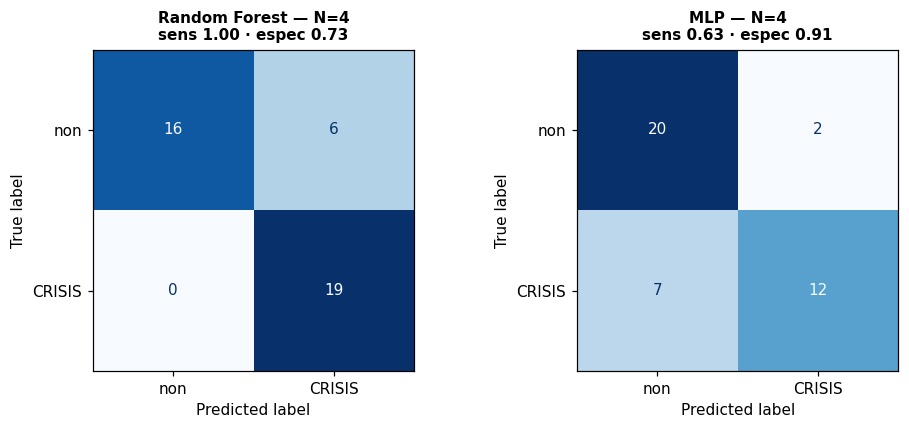

In [ ]:
# ── Explorar N = 4 (el óptimo del MLP) en AMBOS modelos ──
# NOTA: esto es exploratorio. El resultado del informe usa el MISMO N para
# los dos (N=8). Acá solo vemos qué pasa con el MLP en su mejor punto.

DUR_TEST, FRAC_TEST = 4.0, 1.0

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
print(f'{"modelo":<16s}{"sens":>16s}{"espec":>16s}')
print('-'*50)
for a, prob, nom in ((ax[0], RES_RF['prob'], 'Random Forest'),
                     (ax[1], RES_MLP['prob'], 'MLP')):
    corte = cut_operacion(prob)
    yp = np.array([1 if hay_crisis(prob, f, corte, DUR_TEST, FRAC_TEST) else 0 for f in FIDS])
    cm = confusion_matrix(y_true_frag, yp, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
    sens = tp/(tp+fn) if (tp+fn) else float('nan')
    esp  = tn/(tn+fp) if (tn+fp) else float('nan')
    print(f'{nom:<16s}{sens:>8.3f} ({tp}/{tp+fn}){esp:>8.3f} ({tn}/{tn+fp})')
    ConfusionMatrixDisplay(cm, display_labels=['non','CRISIS']).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(f'{nom} — N=4\nsens {sens:.2f} · espec {esp:.2f}', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

modelo                      sens           espec
--------------------------------------------------
Random Forest      0.947 (18/19)   0.955 (21/22)
MLP                0.158 (3/19)   1.000 (22/22)


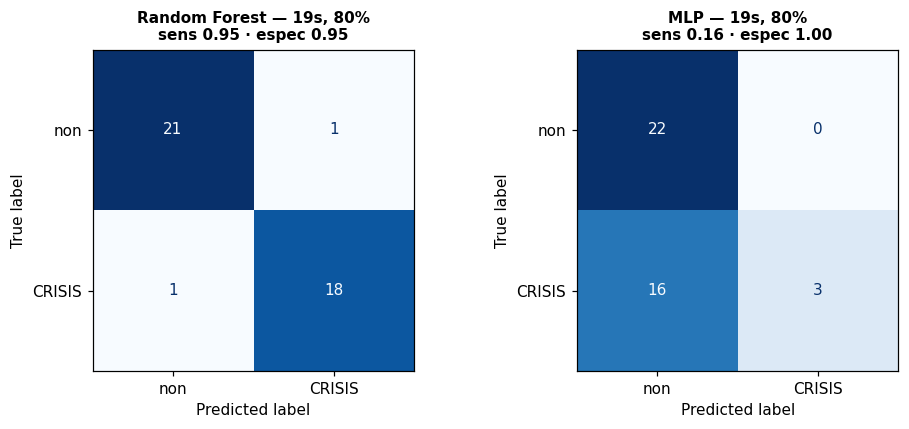

In [ ]:
# ── Probar franja larga: DUR_S = 19 s, frac_min = 0.8 ──
# (exploratorio: se espera colapso de sensibilidad, ver nota abajo)
DUR_TEST, FRAC_TEST = 19.0, 0.8

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
print(f'{"modelo":<16s}{"sens":>16s}{"espec":>16s}')
print('-'*50)
for a, prob, nom in ((ax[0], RES_RF['prob'], 'Random Forest'),
                     (ax[1], RES_MLP['prob'], 'MLP')):
    corte = cut_operacion(prob)
    yp = np.array([1 if hay_crisis(prob, f, corte, DUR_TEST, FRAC_TEST) else 0 for f in FIDS])
    cm = confusion_matrix(y_true_frag, yp, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
    sens = tp/(tp+fn) if (tp+fn) else float('nan')
    esp  = tn/(tn+fp) if (tn+fp) else float('nan')
    print(f'{nom:<16s}{sens:>8.3f} ({tp}/{tp+fn}){esp:>8.3f} ({tn}/{tn+fp})')
    ConfusionMatrixDisplay(cm, display_labels=['non','CRISIS']).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(f'{nom} — {DUR_TEST:.0f}s, {int(FRAC_TEST*100)}%\nsens {sens:.2f} · espec {esp:.2f}',
                fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
# ── Desglose por fragmento con criterio 19s / 80% ──
DUR_TEST, FRAC_TEST = 19.0, 0.8

def desglose(prob, nombre):
    corte = cut_operacion(prob)
    print(f'\n{"="*70}\n{nombre}  ·  corte {corte:.3f}  ·  franja {DUR_TEST:.0f}s · {int(FRAC_TEST*100)}%\n{"="*70}')
    print(f'{"fragmento":<26s}{"rata":>8s}{"real":>8s}{"predicho":>10s}{"caso":>8s}')
    print('-'*70)
    err = {'FP': [], 'FN': []}
    for f, yt in sorted(zip(FIDS, y_true_frag), key=lambda z: (ETIQ[z[0]]['rata'], z[0])):
        yp = 1 if hay_crisis(prob, f, corte, DUR_TEST, FRAC_TEST) else 0
        real = 'CRISIS' if yt else 'non'
        pred = 'CRISIS' if yp else 'non'
        if   yt == 1 and yp == 1: caso = 'TP'
        elif yt == 0 and yp == 0: caso = 'TN'
        elif yt == 0 and yp == 1: caso = 'FP ✗'; err['FP'].append((f, ETIQ[f]['rata']))
        else:                     caso = 'FN ✗'; err['FN'].append((f, ETIQ[f]['rata']))
        print(f'{f:<26s}{ETIQ[f]["rata"]:>8s}{real:>8s}{pred:>10s}{caso:>8s}')

    print(f'\n  ── ERRORES de {nombre} ──')
    if err['FP']:
        print(f'  Falsos positivos (non→CRISIS): {len(err["FP"])}')
        for f, r in err['FP']: print(f'      {r:<8s} {f}')
    else:
        print('  Falsos positivos: ninguno')
    if err['FN']:
        print(f'  Falsos negativos (CRISIS→non): {len(err["FN"])}')
        for f, r in err['FN']: print(f'      {r:<8s} {f}')
    else:
        print('  Falsos negativos: ninguno')

    from collections import Counter
    ratas_err = Counter(r for _, r in err['FP'] + err['FN'])
    if ratas_err:
        print(f'\n  Ratas con algún error: '
              + ', '.join(f'{r}({n})' for r, n in ratas_err.most_common()))
    return err

err_rf  = desglose(RES_RF['prob'],  'Random Forest')
err_mlp = desglose(RES_MLP['prob'], 'MLP')


Random Forest  ·  corte 0.026  ·  franja 19s · 80%
fragmento                     rata    real  predicho    caso
----------------------------------------------------------------------
B6_2023_7_23-non1            RatB6     non       non      TN
B6_2023_7_23-non2            RatB6     non       non      TN
B6_2023_7_24-ictal1          RatB6  CRISIS    CRISIS      TP
B6_2023_7_25-ictal1          RatB6  CRISIS    CRISIS      TP
C16_2023_10_30-ictal1       RatC16  CRISIS    CRISIS      TP
C16_2023_10_31-ictal1       RatC16  CRISIS    CRISIS      TP
C16_2023_11_1-non1          RatC16     non       non      TN
C16_2023_11_1-non2          RatC16     non       non      TN
C3_2023_10_20-non1           RatC3     non       non      TN
C3_2023_10_20-non2           RatC3     non       non      TN
C3_2023_10_23-ictal1         RatC3  CRISIS    CRISIS      TP
C3_2023_10_24-ictal1         RatC3  CRISIS    CRISIS      TP
D17_2024_1_2-non1           RatD17     non       non      TN
D17_2024_1_2-non2      

In [ ]:
fid = 'Z11_2021_11_19-ictal1'
print('SIG existe:', 'SIG' in dir(), '| fid en SIG:', fid in SIG if 'SIG' in dir() else '—')
if 'SIG' in dir() and fid in SIG:
    print('shape:', SIG[fid].shape, '| FS:', FS)
print('onset (ETIQ):', ETIQ[fid]['ictal'], '→ onset ≈', ETIQ[fid]['ictal'][0]-10, 's')

SIG existe: True | fid en SIG: True
shape: (300000, 12) | FS: 500
onset (ETIQ): (np.float64(132.796), np.float64(152.796)) → onset ≈ 122.79599999999999 s


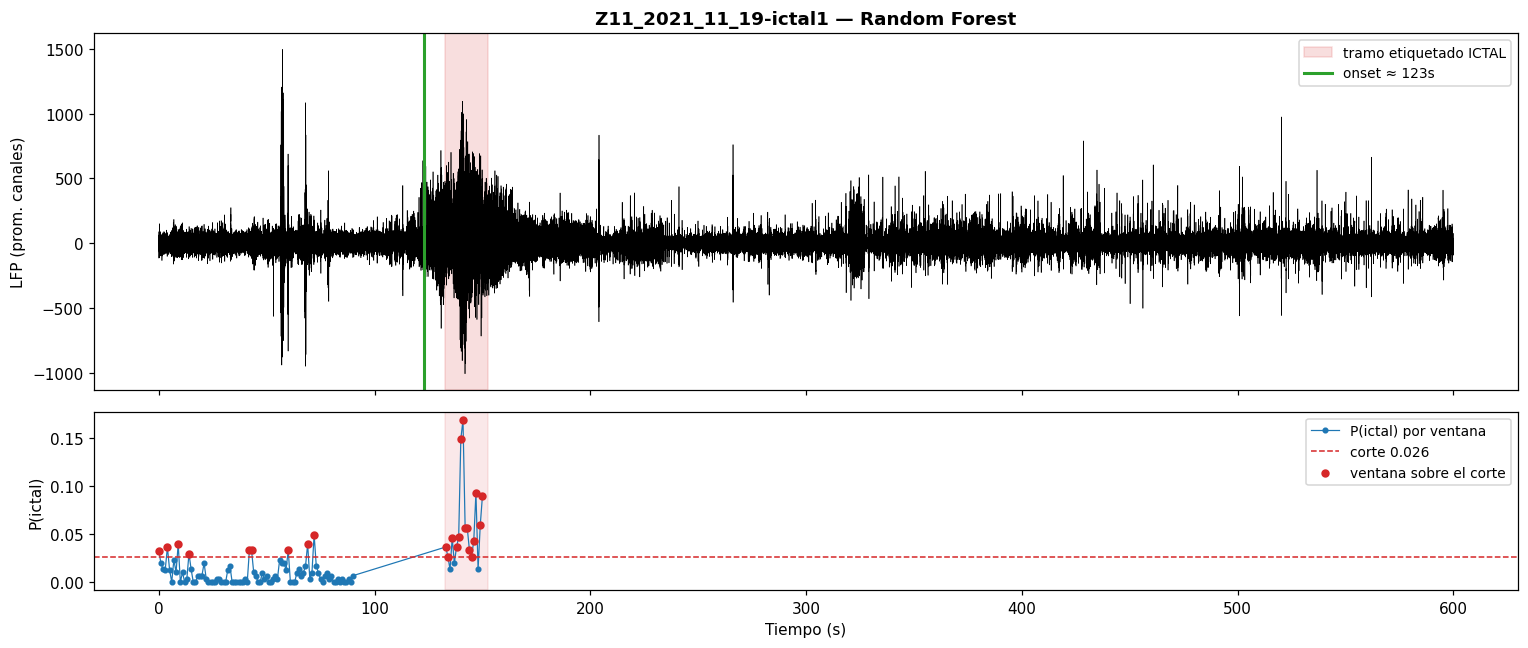


Ventanas sobre el corte en el tramo ictal: 24/109
Racha máxima consecutiva: 10 ventanas
Con 8s/100% detecta: SÍ  ·  con 19s/80% detecta: SÍ


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fid  = 'Z11_2021_11_19-ictal1'
prob = RES_RF['prob']          # cambiá a RES_MLP['prob'] para ver el MLP
nombre = 'Random Forest'
corte = cut_operacion(prob)

# --- señal cruda: promedio de canales para una vista global (o elegí uno) ---
sig = SIG[fid]
t_sig = np.arange(sig.shape[0]) / FS
canal = sig.mean(axis=1)       # o sig[:, 0] para el canal 0

# --- ventanas del fragmento, ordenadas, con su prob ---
idx   = _orden[fid]
t_win = tiempo[idx]
p_win = prob[idx]
sobre = p_win >= corte

# --- tramo etiquetado ictal y onset ---
ini_ict, fin_ict = ETIQ[fid]['ictal']
onset = ini_ict - 10.0

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                       gridspec_kw={'height_ratios':[2,1]})

# Panel 1: señal cruda + zonas
ax[0].plot(t_sig, canal, lw=0.4, color='black')
ax[0].axvspan(ini_ict, fin_ict, color='tab:red', alpha=0.15, label='tramo etiquetado ICTAL')
ax[0].axvline(onset, color='tab:green', lw=2, label=f'onset ≈ {onset:.0f}s')
ax[0].set_ylabel('LFP (prom. canales)'); ax[0].legend(loc='upper right', fontsize=9)
ax[0].set_title(f'{fid} — {nombre}', fontweight='bold')

# Panel 2: probabilidad por ventana + corte + ventanas que disparan
ax[1].plot(t_win, p_win, 'o-', ms=3, lw=0.8, color='tab:blue', label='P(ictal) por ventana')
ax[1].axhline(corte, color='tab:red', ls='--', lw=1, label=f'corte {corte:.3f}')
ax[1].scatter(t_win[sobre], p_win[sobre], color='tab:red', s=20, zorder=5,
              label='ventana sobre el corte')
ax[1].axvspan(ini_ict, fin_ict, color='tab:red', alpha=0.10)
ax[1].set_xlabel('Tiempo (s)'); ax[1].set_ylabel('P(ictal)')
ax[1].legend(loc='upper right', fontsize=9)

plt.tight_layout(); plt.show()

# --- resumen: ¿cuántas ventanas seguidas logra? ---
def racha_max(sobre_arr):
    m = r = 0
    for s in sobre_arr:
        r = r+1 if s else 0; m = max(m, r)
    return m
print(f'\nVentanas sobre el corte en el tramo ictal: {sobre.sum()}/{len(sobre)}')
print(f'Racha máxima consecutiva: {racha_max(sobre)} ventanas')
print(f'Con 8s/100% detecta: {"SÍ" if racha_max(sobre)>=8 else "NO"}  ·  '
      f'con 19s/80% detecta: {"SÍ" if sobre.sum()/max(1,round(19/STEP_S))>=0.8 else "NO"}')

In [ ]:
fid = 'B6_2023_7_24-ictal1'   # un ictal que detecta bien, para que se vea claro
print('SIG existe:', 'SIG' in dir())
if 'SIG' in dir():
    print('fid en SIG:', fid in SIG, '| shape:', SIG[fid].shape if fid in SIG else '—', '| FS:', FS)
print('ETIQ[fid]:', ETIQ[fid])

SIG existe: True
fid en SIG: True | shape: (300000, 12) | FS: 500
ETIQ[fid]: {'rata': 'RatB6', 'onset': np.float64(317.634), 'interictal': (0.0, np.float64(287.634)), 'ictal': (np.float64(327.634), np.float64(347.634))}


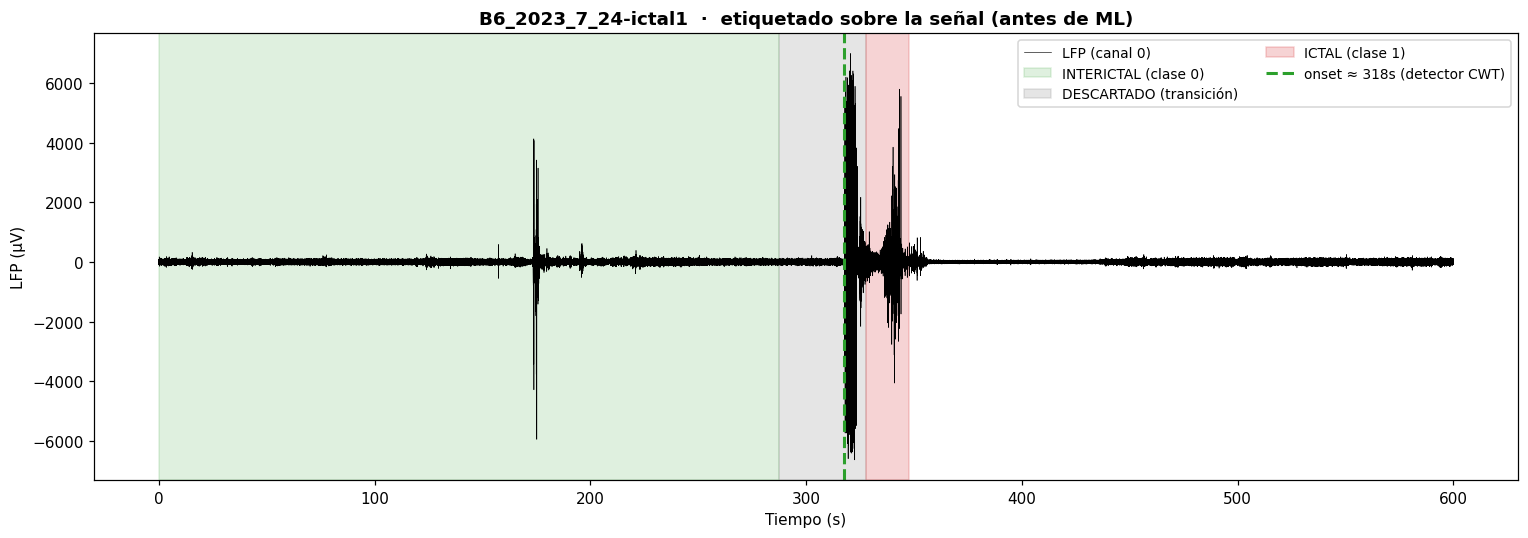

onset ≈ 318s  ·  interictal: 0–288s  ·  ictal: 328–348s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fid = 'B6_2023_7_24-ictal1'   # cambialo por el que quieras ver

sig   = SIG[fid]
t     = np.arange(sig.shape[0]) / FS
e     = ETIQ[fid]
inter = e['interictal']              # (0, onset-30)
ict   = e['ictal']                   # (onset+10, onset+30)
onset = ict[0] - 10.0

fig, ax = plt.subplots(figsize=(14, 5))

# señal: un par de canales representativos (o el promedio)
ax.plot(t, sig[:, 0], lw=0.4, color='black', label='LFP (canal 0)')

# zonas de etiquetado
ax.axvspan(inter[0], inter[1], color='tab:green', alpha=0.15, label='INTERICTAL (clase 0)')
ax.axvspan(inter[1], ict[0],   color='gray',      alpha=0.20, label='DESCARTADO (transición)')
ax.axvspan(ict[0],   ict[1],   color='tab:red',   alpha=0.20, label='ICTAL (clase 1)')
ax.axvline(onset, color='tab:green', lw=2, ls='--', label=f'onset ≈ {onset:.0f}s (detector CWT)')

ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('LFP (µV)')
ax.set_title(f'{fid}  ·  etiquetado sobre la señal (antes de ML)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

print(f'onset ≈ {onset:.0f}s  ·  interictal: {inter[0]:.0f}–{inter[1]:.0f}s  ·  '
      f'ictal: {ict[0]:.0f}–{ict[1]:.0f}s')

In [ ]:
for fid in ['B6_2023_7_24-ictal1', 'D17_2024_1_4-ictal1']:
    print(fid, '| en SIG:', fid in SIG, '| ictal:', ETIQ[fid]['ictal'])
print('FS:', FS, '| DUR_S:', DUR_S, '| FRAC_MIN:', FRAC_MIN)

B6_2023_7_24-ictal1 | en SIG: True | ictal: (np.float64(327.634), np.float64(347.634))
D17_2024_1_4-ictal1 | en SIG: True | ictal: (np.float64(315.084), np.float64(335.084))
FS: 500 | DUR_S: 8.0 | FRAC_MIN: 1.0


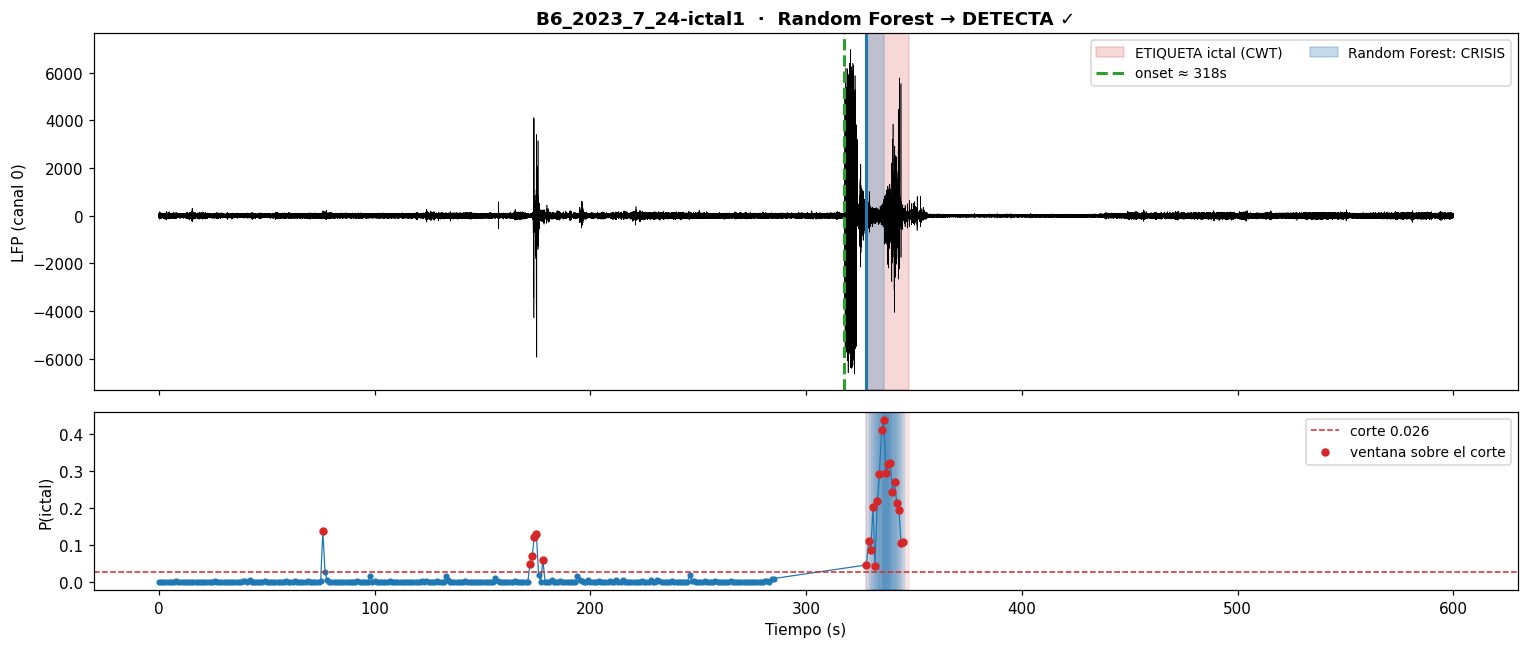

B6_2023_7_24-ictal1: detecta · 1er disparo ≈ 328s · onset ≈ 318s · latencia +10s


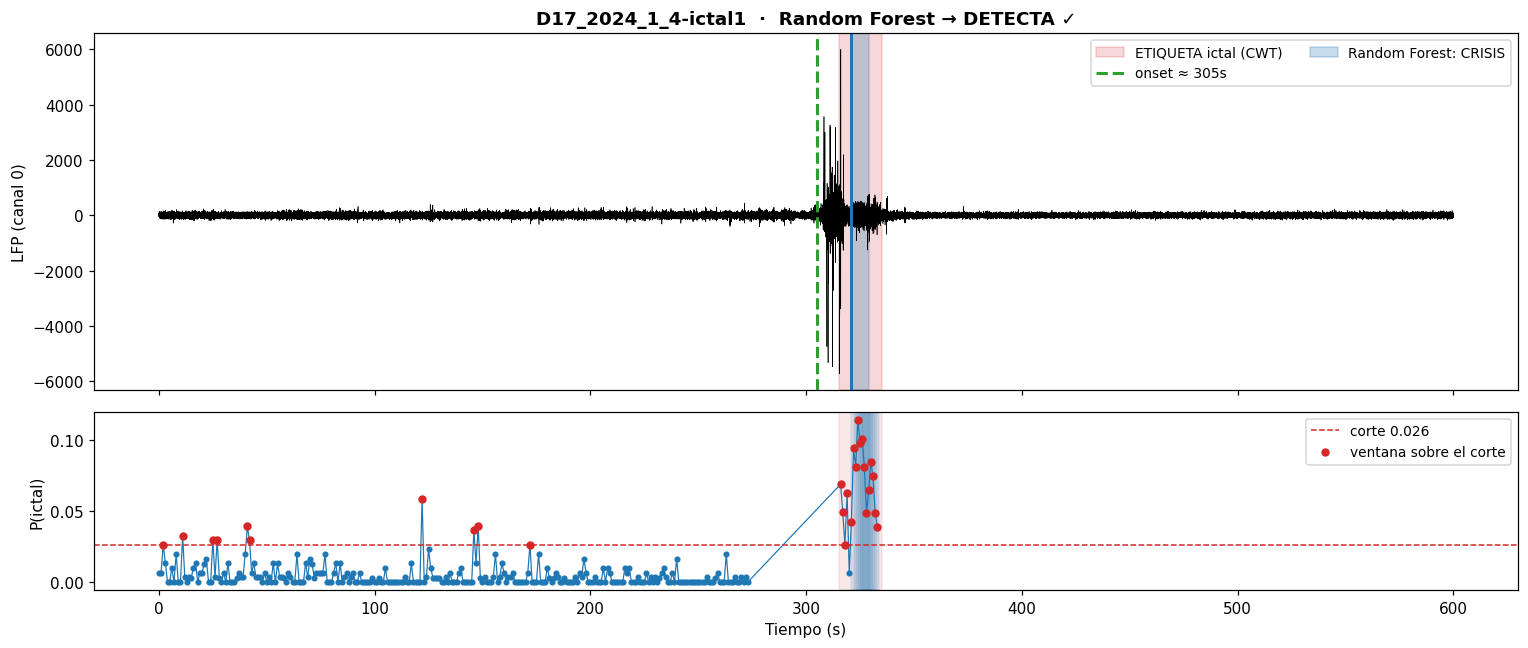

D17_2024_1_4-ictal1: detecta · 1er disparo ≈ 321s · onset ≈ 305s · latencia +16s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_etiqueta_vs_ml(fid, prob, nombre_modelo):
    sig   = SIG[fid]
    t     = np.arange(sig.shape[0]) / FS
    e     = ETIQ[fid]
    ict   = e['ictal']
    onset = ict[0] - 10.0
    corte = cut_operacion(prob)

    # ventanas del fragmento ordenadas + prob + cuáles superan el corte
    idx   = _orden[fid]
    t_win = tiempo[idx]
    p_win = prob[idx]
    sobre = p_win >= corte

    # reconstruir la(s) franja(s) que gatillan crisis (misma lógica que hay_crisis)
    n_slots = max(1, round(DUR_S / STEP_S))
    disparos = []
    for i in range(len(t_win)):
        en = (t_win >= t_win[i]) & (t_win < t_win[i] + DUR_S)
        if sobre[en].sum() / n_slots >= FRAC_MIN:
            disparos.append((t_win[i], t_win[i] + DUR_S))
    detecta = len(disparos) > 0

    fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                           gridspec_kw={'height_ratios': [2, 1]})

    # Panel 1 — señal + ETIQUETA ictal + primer disparo del ML
    ax[0].plot(t, sig[:, 0], lw=0.4, color='black')
    ax[0].axvspan(ict[0], ict[1], color='tab:red', alpha=0.18, label='ETIQUETA ictal (CWT)')
    ax[0].axvline(onset, color='tab:green', lw=2, ls='--', label=f'onset ≈ {onset:.0f}s')
    if detecta:
        d0, d1 = disparos[0]
        ax[0].axvspan(d0, d1, color='tab:blue', alpha=0.25, label=f'{nombre_modelo}: CRISIS')
        ax[0].axvline(d0, color='tab:blue', lw=2)
    ax[0].set_ylabel('LFP (canal 0)')
    ax[0].legend(loc='upper right', fontsize=9, ncol=2)
    estado = 'DETECTA ✓' if detecta else 'NO detecta ✗'
    ax[0].set_title(f'{fid}  ·  {nombre_modelo} → {estado}', fontweight='bold')

    # Panel 2 — probabilidad por ventana
    ax[1].plot(t_win, p_win, 'o-', ms=3, lw=0.8, color='tab:blue')
    ax[1].axhline(corte, color='tab:red', ls='--', lw=1, label=f'corte {corte:.3f}')
    ax[1].scatter(t_win[sobre], p_win[sobre], color='tab:red', s=20, zorder=5,
                  label='ventana sobre el corte')
    ax[1].axvspan(ict[0], ict[1], color='tab:red', alpha=0.10)
    for d0, d1 in disparos:
        ax[1].axvspan(d0, d1, color='tab:blue', alpha=0.12)
    ax[1].set_xlabel('Tiempo (s)'); ax[1].set_ylabel('P(ictal)')
    ax[1].legend(loc='upper right', fontsize=9)
    plt.tight_layout(); plt.show()

    # latencia: primer disparo dentro/después del onset vs onset
    if detecta:
        post = [d0 for d0, _ in disparos if d0 >= onset - DUR_S]
        t_disp = min(post) if post else disparos[0][0]
        print(f'{fid}: detecta · 1er disparo ≈ {t_disp:.0f}s · onset ≈ {onset:.0f}s · '
              f'latencia {t_disp - onset:+.0f}s')
    else:
        print(f'{fid}: NO detecta')

# B6 (RF lo clasifica bien) y otra rata para contrastar
graficar_etiqueta_vs_ml('B6_2023_7_24-ictal1', RES_RF['prob'], 'Random Forest')
graficar_etiqueta_vs_ml('D17_2024_1_4-ictal1', RES_RF['prob'], 'Random Forest')

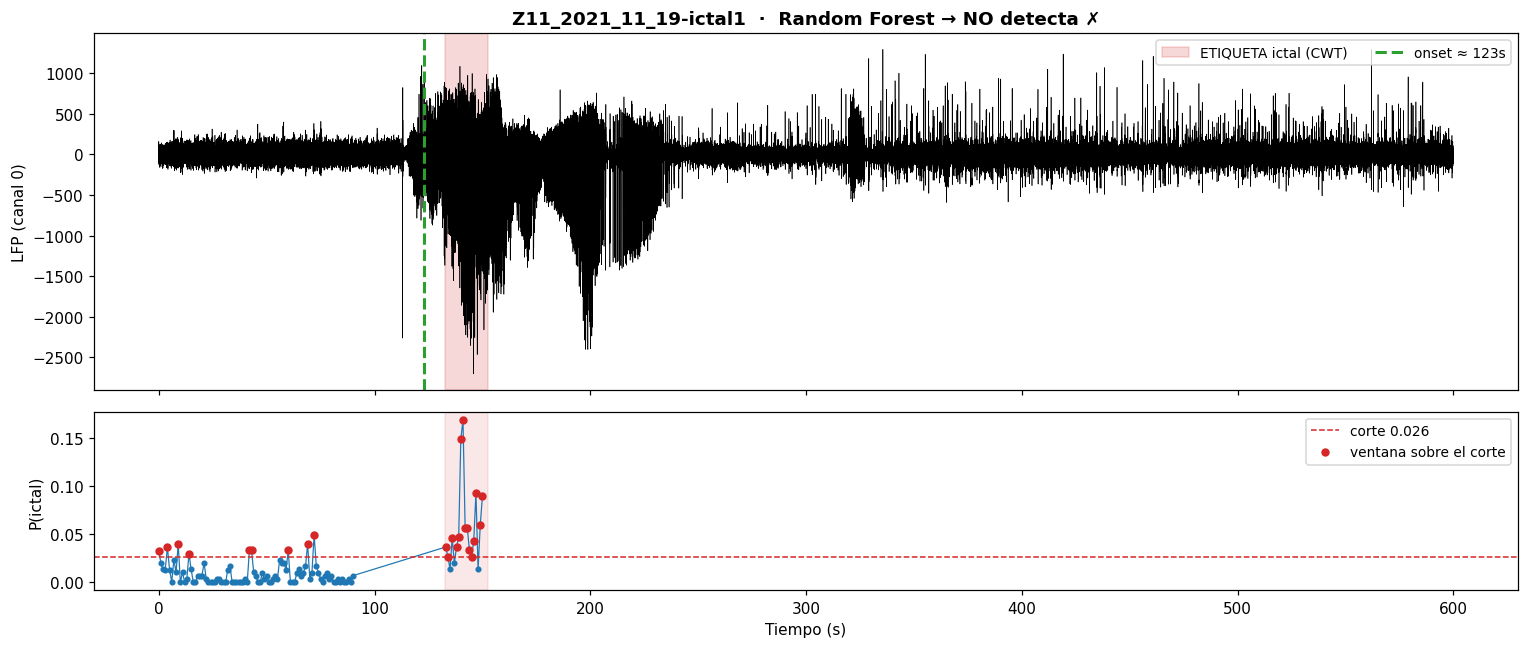

Z11_2021_11_19-ictal1: NO detecta


In [ ]:
# --- fijar el criterio 19s/80% para reproducir el fallo de Z11 ---
DUR_S, FRAC_MIN = 19.0, 0.8

graficar_etiqueta_vs_ml('Z11_2021_11_19-ictal1', RES_RF['prob'], 'Random Forest')

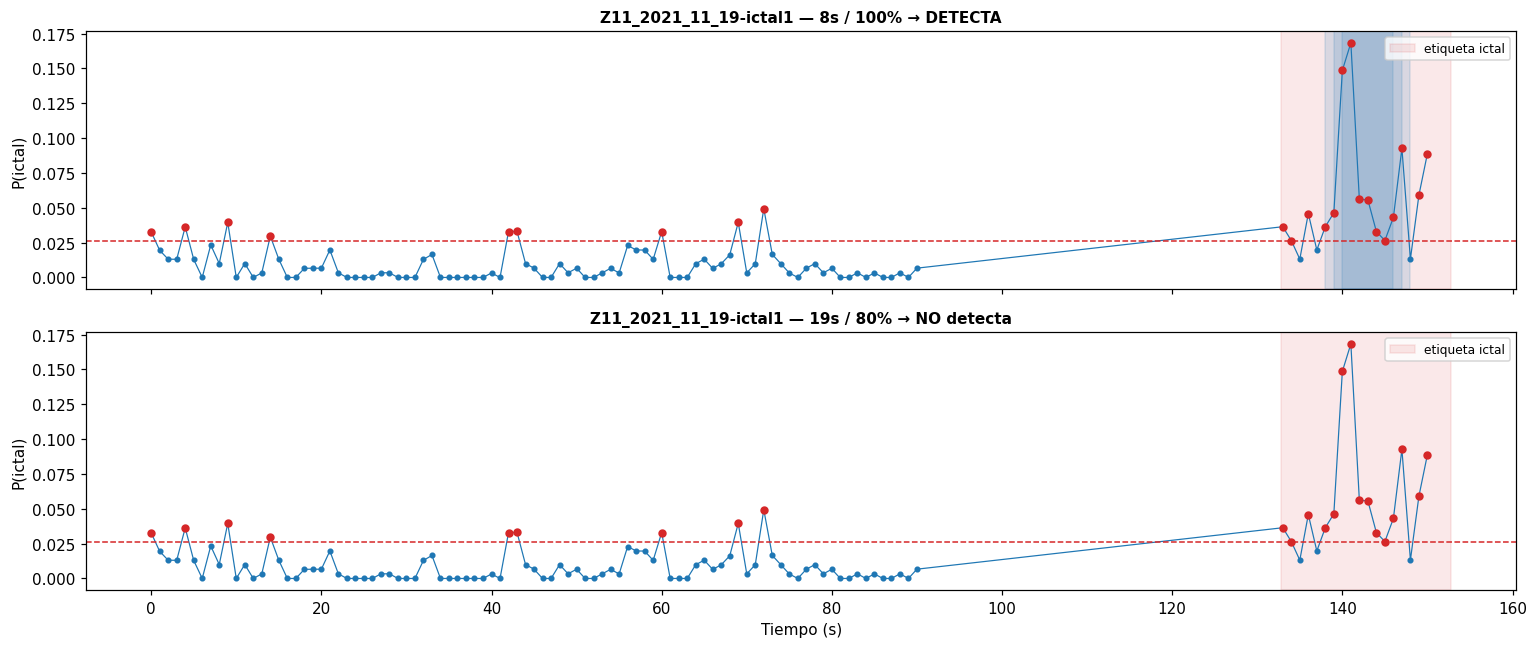

Ventanas sobre el corte en el tramo ictal: 24/109
Fracción en 8s más densa vs 19s: alcanza 100% de 8s = SÍ · 80% de 19s = NO


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fid = 'Z11_2021_11_19-ictal1'
prob = RES_RF['prob']
corte = cut_operacion(prob)
idx = _orden[fid]; t_win = tiempo[idx]; p_win = prob[idx]; sobre = p_win >= corte
e = ETIQ[fid]; ict = e['ictal']

def disparos_criterio(dur_s, frac_min):
    ns = max(1, round(dur_s/STEP_S)); out = []
    for i in range(len(t_win)):
        en = (t_win >= t_win[i]) & (t_win < t_win[i] + dur_s)
        if sobre[en].sum()/ns >= frac_min: out.append((t_win[i], t_win[i]+dur_s))
    return out

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for a, (dur, frac, tit) in zip(ax, [(8.0, 1.0, '8s / 100% → DETECTA'),
                                    (19.0, 0.8, '19s / 80% → NO detecta')]):
    a.plot(t_win, p_win, 'o-', ms=3, lw=0.8, color='tab:blue')
    a.axhline(corte, color='tab:red', ls='--', lw=1)
    a.scatter(t_win[sobre], p_win[sobre], color='tab:red', s=20, zorder=5)
    a.axvspan(ict[0], ict[1], color='tab:red', alpha=0.10, label='etiqueta ictal')
    disp = disparos_criterio(dur, frac)
    for d0, d1 in disp:
        a.axvspan(d0, d1, color='tab:blue', alpha=0.15)
    a.set_ylabel('P(ictal)'); a.set_title(f'{fid} — {tit}', fontweight='bold', fontsize=10)
    a.legend(loc='upper right', fontsize=8)
ax[1].set_xlabel('Tiempo (s)')
plt.tight_layout(); plt.show()

# resumen numérico
ns8, ns19 = round(8/STEP_S), round(19/STEP_S)
print(f'Ventanas sobre el corte en el tramo ictal: {sobre.sum()}/{len(sobre)}')
print(f'Fracción en 8s más densa vs 19s: alcanza 100% de 8s = {"SÍ" if disparos_criterio(8,1.0) else "NO"} · '
      f'80% de 19s = {"SÍ" if disparos_criterio(19,0.8) else "NO"}')

CLASIFICACIÓN POR VENTANA (2 s) · corte de operación por modelo
modelo             corte    sens   espec    prec   ictal tp/fn
------------------------------------------------------------------
Random Forest      0.026   0.965   0.896   0.149     330/12   
MLP                0.007   0.430   0.959   0.166     147/195  


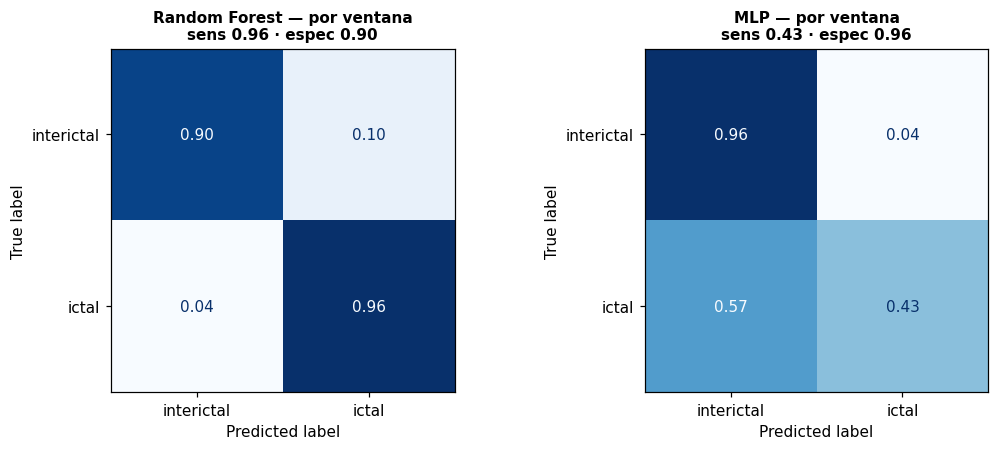

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  MATRICES DE CONFUSIÓN POR VENTANA — RF y MLP  (complementa las de fragmento)
# ═══════════════════════════════════════════════════════════════════════════
# Reusa: RES_RF['prob'], RES_MLP['prob'], y, cut_operacion.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def eval_ventana(prob, nombre):
    m = np.isfinite(prob)                 # ignora ventanas sin predicción
    yv, pv = y[m], prob[m]
    corte = cut_operacion(prob)           # mismo punto de operación (Youden)
    pred = (pv >= corte).astype(int)
    cm = confusion_matrix(yv, pred, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
    sens = tp/(tp+fn) if (tp+fn) else np.nan
    esp  = tn/(tn+fp) if (tn+fp) else np.nan
    prec = tp/(tp+fp) if (tp+fp) else np.nan
    return dict(nombre=nombre, cm=cm, corte=corte, sens=sens, esp=esp, prec=prec,
                tn=tn, fp=fp, fn=fn, tp=tp)

R = [eval_ventana(RES_RF['prob'], 'Random Forest'),
     eval_ventana(RES_MLP['prob'], 'MLP')]

# tabla
print('='*66)
print('CLASIFICACIÓN POR VENTANA (2 s) · corte de operación por modelo')
print('='*66)
print(f'{"modelo":<16s}{"corte":>8s}{"sens":>8s}{"espec":>8s}{"prec":>8s}'
      f'{"ictal tp/fn":>14s}')
print('-'*66)
for r in R:
    print(f'{r["nombre"]:<16s}{r["corte"]:>8.3f}{r["sens"]:>8.3f}{r["esp"]:>8.3f}'
          f'{r["prec"]:>8.3f}{r["tp"]:>8d}/{r["fn"]:<5d}')

# figura: dos matrices lado a lado (normalizadas por fila para leer % por clase)
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
for a, r in zip(ax, R):
    cmn = r['cm'].astype(float) / r['cm'].sum(axis=1, keepdims=True)  # % por clase real
    disp = ConfusionMatrixDisplay(cmn, display_labels=['interictal', 'ictal'])
    disp.plot(ax=a, cmap='Blues', colorbar=False, values_format='.2f')
    a.set_title(f'{r["nombre"]} — por ventana\nsens {r["sens"]:.2f} · espec {r["esp"]:.2f}',
                fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
r3 = [f for f in SIG if 'R3' in f]
print('Fragmentos de R3 en SIG:', r3)
for f in r3:
    et = ETIQ[f]['ictal'] if f in ETIQ else 'NO está en ETIQ (sin onset)'
    print(f'  {f:<26s} shape {SIG[f].shape} · ictal={et}')

Fragmentos de R3 en SIG: ['R3_2022_3_19-ictal1', 'R3_2022_3_20-ictal1', 'R3_2022_3_16-non1', 'R3_2022_3_16-non2']
  R3_2022_3_19-ictal1        shape (300000, 12) · ictal=NO está en ETIQ (sin onset)
  R3_2022_3_20-ictal1        shape (300000, 12) · ictal=NO está en ETIQ (sin onset)
  R3_2022_3_16-non1          shape (300000, 12) · ictal=None
  R3_2022_3_16-non2          shape (300000, 12) · ictal=None


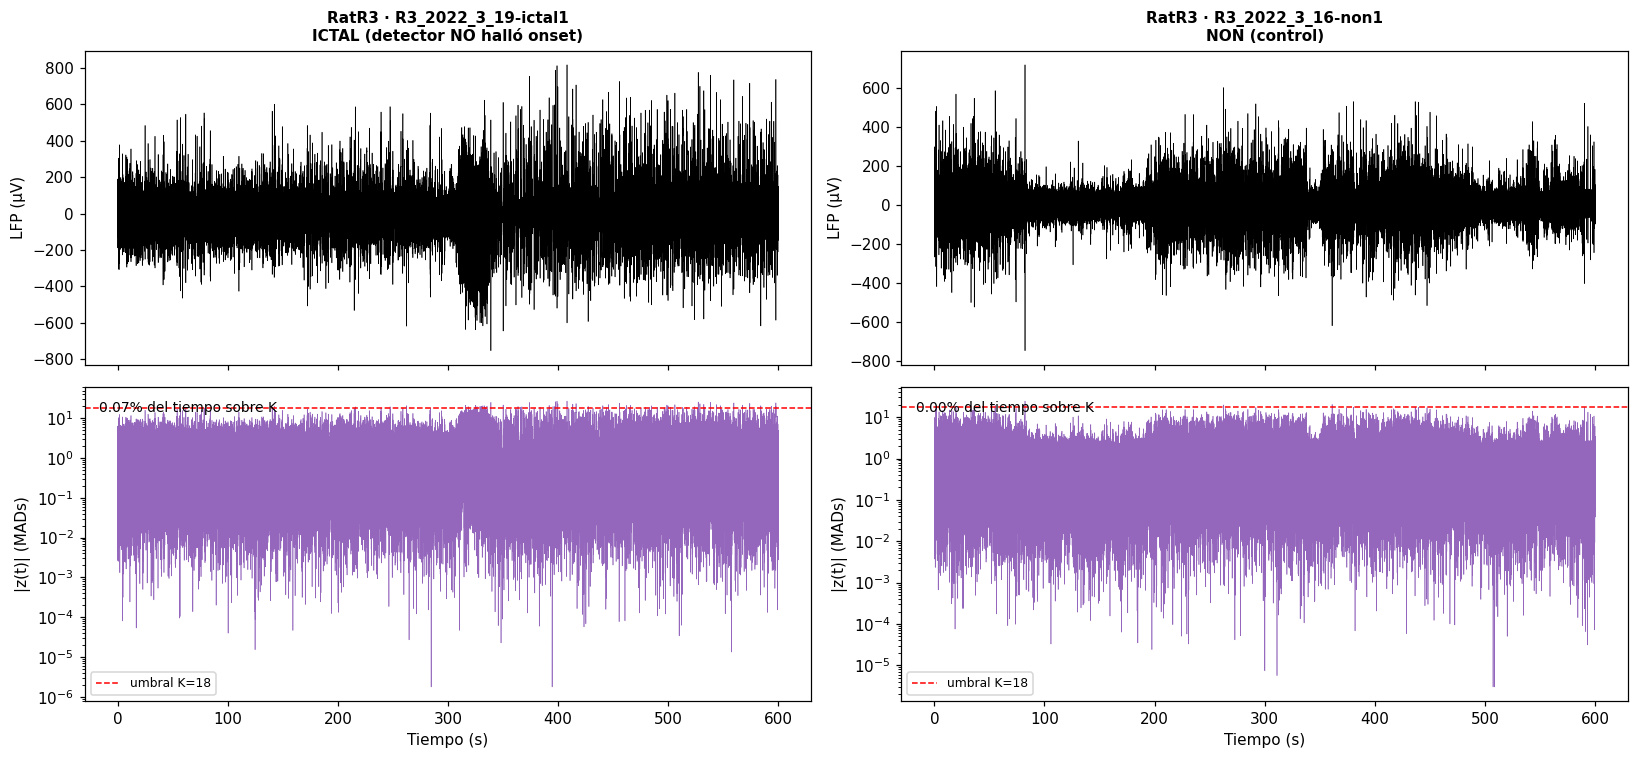

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

FID_ICTAL = 'R3_2022_3_19-ictal1'   # ictal sin onset
FID_NON   = 'R3_2022_3_16-non1'     # control
K = 18

def z_robusto(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-9
    return (x - med) / mad

fig, ax = plt.subplots(2, 2, figsize=(15, 7), sharex='col')

for col, (fid, titulo) in enumerate([(FID_ICTAL, 'ICTAL (detector NO halló onset)'),
                                      (FID_NON,   'NON (control)')]):
    sig = SIG[fid]
    t = np.arange(sig.shape[0]) / FS
    ch = sig[:, 0]

    ax[0, col].plot(t, ch, lw=0.4, color='black')
    ax[0, col].set_title(f'RatR3 · {fid}\n{titulo}', fontweight='bold', fontsize=10)
    ax[0, col].set_ylabel('LFP (µV)')

    z = np.abs(z_robusto(ch))
    ax[1, col].plot(t, z, lw=0.4, color='tab:purple')
    ax[1, col].axhline(K, color='red', ls='--', lw=1, label=f'umbral K={K}')
    ax[1, col].set_yscale('log')
    ax[1, col].set_xlabel('Tiempo (s)'); ax[1, col].set_ylabel('|z(t)| (MADs)')
    ax[1, col].legend(fontsize=8)
    frac = (z > K).mean() * 100
    ax[1, col].text(0.02, 0.92, f'{frac:.2f}% del tiempo sobre K',
                    transform=ax[1, col].transAxes, fontsize=9)

plt.tight_layout(); plt.show()

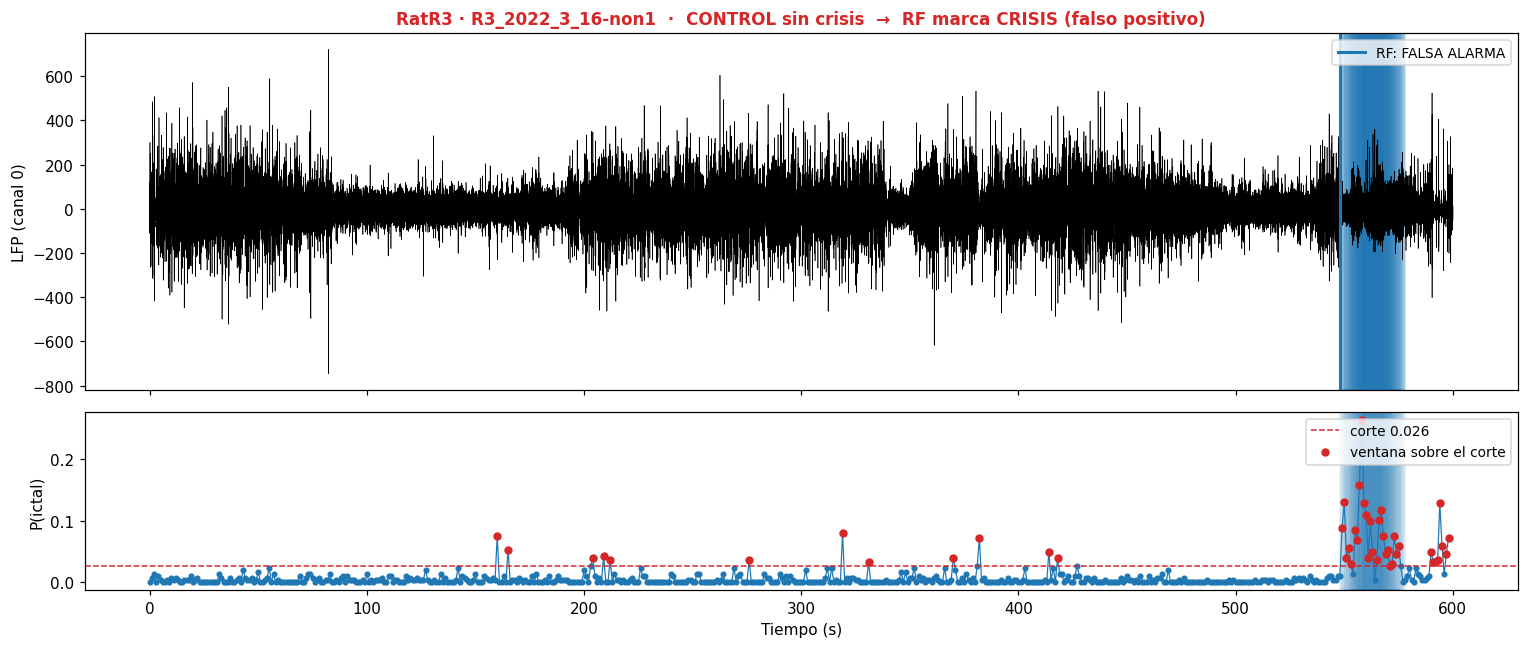

Ventanas sobre el corte: 45/599
¿El criterio 19s/80% gatilla?: SÍ (falso positivo)
Franja que dispara: 548–567s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

FID_FP = 'R3_2022_3_16-non1'    # el control de R3 que el RF marca como crisis
prob   = RES_RF['prob']
corte  = cut_operacion(prob)

sig = SIG[FID_FP]
t   = np.arange(sig.shape[0]) / FS

# ventanas del fragmento ordenadas + prob + cuáles superan el corte
idx   = _orden[FID_FP]
t_win = tiempo[idx]
p_win = prob[idx]
sobre = p_win >= corte

# reconstruir las franjas que gatillan CRISIS (criterio final 19s/80%)
n_slots = max(1, round(DUR_S / STEP_S))
disparos = []
for i in range(len(t_win)):
    en = (t_win >= t_win[i]) & (t_win < t_win[i] + DUR_S)
    if sobre[en].sum() / n_slots >= FRAC_MIN:
        disparos.append((t_win[i], t_win[i] + DUR_S))
detecta = len(disparos) > 0

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                       gridspec_kw={'height_ratios': [2, 1]})

# Panel 1 — señal cruda (es un NON: no hay crisis real) + disparo del ML
ax[0].plot(t, sig[:, 0], lw=0.4, color='black')
for d0, d1 in disparos:
    ax[0].axvspan(d0, d1, color='tab:blue', alpha=0.25)
if detecta:
    ax[0].axvline(disparos[0][0], color='tab:blue', lw=2, label='RF: FALSA ALARMA')
ax[0].set_ylabel('LFP (canal 0)')
ax[0].legend(loc='upper right', fontsize=9)
ax[0].set_title(f'RatR3 · {FID_FP}  ·  CONTROL sin crisis  →  RF marca CRISIS (falso positivo)',
                fontweight='bold', fontsize=11, color='tab:red')

# Panel 2 — probabilidad por ventana
ax[1].plot(t_win, p_win, 'o-', ms=3, lw=0.8, color='tab:blue')
ax[1].axhline(corte, color='tab:red', ls='--', lw=1, label=f'corte {corte:.3f}')
ax[1].scatter(t_win[sobre], p_win[sobre], color='tab:red', s=20, zorder=5,
              label='ventana sobre el corte')
for d0, d1 in disparos:
    ax[1].axvspan(d0, d1, color='tab:blue', alpha=0.12)
ax[1].set_xlabel('Tiempo (s)'); ax[1].set_ylabel('P(ictal)')
ax[1].legend(loc='upper right', fontsize=9)

plt.tight_layout(); plt.show()

print(f'Ventanas sobre el corte: {sobre.sum()}/{len(sobre)}')
print(f'¿El criterio 19s/80% gatilla?: {"SÍ (falso positivo)" if detecta else "NO"}')
if detecta:
    print(f'Franja que dispara: {disparos[0][0]:.0f}–{disparos[0][1]:.0f}s')

In [ ]:
# ¿qué funciones del detector tengo disponibles?
for nombre in ['detectar', 'onset_consenso', 'z_agnostico', 'cwt_potencia',
               'Z_ICT', 'Z_NON', 'K_MAD', 'MIN_CAN', 'DUR_S', 'MARGEN_S']:
    print(f'{nombre:20s}: {"✓ existe" if nombre in dir() else "✗ no está"}')

detectar            : ✓ existe
onset_consenso      : ✗ no está
z_agnostico         : ✓ existe
cwt_potencia        : ✓ existe
Z_ICT               : ✓ existe
Z_NON               : ✓ existe
K_MAD               : ✓ existe
MIN_CAN             : ✓ existe
DUR_S               : ✓ existe
MARGEN_S            : ✓ existe


In [ ]:
for nombre in ['detectar', 'Z_ICT', 'Z_NON', 'SIG', 'K_MAD', 'MIN_CAN', 'DUR_S', 'MARGEN_S', 'FS']:
    print(f'{nombre:12s}: {"✓" if nombre in dir() else "✗"}')

detectar    : ✓
Z_ICT       : ✓
Z_NON       : ✓
SIG         : ✓
K_MAD       : ✓
MIN_CAN     : ✓
DUR_S       : ✓
MARGEN_S    : ✓
FS          : ✓


In [ ]:
fid = 'R3_2022_3_16-non1'

# buscar el z(t) del fragmento en los dicts que puedan tenerlo
z = None
for nombre_dict in ['Z_NON', 'Z_ICT', 'Z']:
    if nombre_dict in dir():
        d = eval(nombre_dict)
        if fid in d:
            z = d[fid]; print(f'z(t) encontrado en {nombre_dict}, shape {z.shape}')
            break

if z is None:
    print('No encontré el z(t) precalculado de este non.')
    print('Dicts disponibles con "Z":', [n for n in dir() if n.startswith('Z')])
else:
    res = detectar(z)     # misma función que etiqueta en la celda 12
    if res is None:
        print(f'\n{fid}: el detector CWT NO dispara → control limpio ✓')
        print('  → El wavelet rechaza el non; solo el Random Forest se equivoca.')
    else:
        print(f'\n{fid}: el detector CWT DISPARA en t={res["onset"]:.1f}s → falso positivo ✗')
        print('  → Tanto el wavelet como el RF marcan este control (anomalía real en la señal).')

z(t) encontrado en Z_NON, shape (12, 300000)

R3_2022_3_16-non1: el detector CWT NO dispara → control limpio ✓
  → El wavelet rechaza el non; solo el Random Forest se equivoca.


In [ ]:
# ── Control de especificidad del detector CWT sobre TODOS los non ──
non_fids = sorted([f for f in Z_NON])   # todos los fragmentos non
print(f'Control de especificidad del detector CWT · {len(non_fids)} fragmentos non\n')
print(f'{"fragmento":<26s}{"rata":>8s}{"resultado":>28s}')
print('-'*62)

fps = []
for fid in non_fids:
    res = detectar(Z_NON[fid])
    rata = ETIQ[fid]['rata'] if fid in ETIQ else fid.split('_')[0]
    if res is None:
        estado = '✓ rechaza (sin detección)'
    else:
        estado = f'✗ DISPARA @ {res["onset"]:.0f}s'
        fps.append((fid, rata, res['onset']))
    print(f'{fid:<26s}{rata:>8s}{estado:>28s}')

print('-'*62)
print(f'\nRESUMEN:')
print(f'  Rechaza limpiamente : {len(non_fids)-len(fps)}/{len(non_fids)} controles')
print(f'  Falsos positivos     : {len(fps)}/{len(non_fids)}')
if fps:
    print('\n  Detalle de falsos positivos:')
    for fid, rata, onset in fps:
        print(f'    {rata:<8s} {fid:<26s} @ {onset:.0f}s')
    ratas_fp = sorted(set(r for _, r, _ in fps))
    print(f'\n  Ratas con falso positivo: {", ".join(ratas_fp)}')
else:
    print('\n  Ningún falso positivo — el detector rechaza todos los controles ✓')

Control de especificidad del detector CWT · 22 fragmentos non

fragmento                     rata                   resultado
--------------------------------------------------------------
B6_2023_7_23-non1            RatB6   ✓ rechaza (sin detección)
B6_2023_7_23-non2            RatB6   ✓ rechaza (sin detección)
C16_2023_11_1-non1          RatC16   ✓ rechaza (sin detección)
C16_2023_11_1-non2          RatC16   ✓ rechaza (sin detección)
C3_2023_10_20-non1           RatC3   ✓ rechaza (sin detección)
C3_2023_10_20-non2           RatC3   ✓ rechaza (sin detección)
D17_2024_1_2-non1           RatD17   ✓ rechaza (sin detección)
D17_2024_1_2-non2           RatD17   ✓ rechaza (sin detección)
E2_2019_7_5-non1             RatE2   ✓ rechaza (sin detección)
E2_2019_7_5-non2             RatE2   ✓ rechaza (sin detección)
E5_2019_5_26-non1            RatE5             ✗ DISPARA @ 16s
E5_2019_5_26-non2            RatE5   ✓ rechaza (sin detección)
R2_2022_4_25-non1            RatR2   ✓ rechaza (sin det